# EDA-анализ для задачи Entity Resolution клиентов маркетплейса

In [ ]:
pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.8 MB/s eta 0:00:00


In [1]:
import json
import math
import re
import warnings
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Загрузка данных

По умолчанию ноутбук ищет файл в текущей директории. Если имя файла отличается, поменяйте значение `DATA_PATH`.

In [3]:
file_path = 'content/split_label_train_V3.snappy.parquet'
df = pd.read_parquet(file_path)

print(f"Размер исходного датасета: {df.shape[0]:,} строк {df.shape[1]:,} колонок")
display(df.head())

Размер исходного датасета: 68,036 строк 12 колонок


,created_at,first_name,last_name,email,phone,birthday,sex,non_processing_features,realtime_features,fs_features,profile_id,entity_id
0,2025-11-01 00:27:04.995,Анфиса,None,lqvxvltxx@mail.ru,None,None,female,"[device:smartphone, geoname_id:2013348, browser:chrome, osfamily:android, subdivision_1_iso_code:PRI]","{""country"":""RU"",""is_million"":false,""tz_offset"":10,""geoname"":""Vladivostok"",""geoid"":2013348,""local_hour"":10,""day"":5,""population"":604901}","[visited_30:250, visited_365:1813, visited_30:1805]",b25135c7-b4f8-3552-8eb6-46331ceea5c9,7266581b455c33f90f4e2418ab7d12e3ec704935338ecf828f6621b6b68a8da9
1,2025-11-01 00:38:35.323,Надежда,None,kstpnq.6751@mail.ru,None,None,female,"[device:smartphone, geoname_id:2025339, browser:yandex, subdivision_1_iso_code:ZAB, osfamily:android]","{""country"":""RU"",""is_million"":false,""tz_offset"":9,""geoname"":""Chita"",""geoid"":2025339,""local_hour"":9,""day"":5,""population"":349005}",[source_site_365:6370],2403b42b-2420-35c2-ac8e-e6572c2920f6,bd0dc28d66040e40ad5303a3ed8f3988973726bb3d03075777796427ff325c4e
2,2025-11-01 00:47:20.741,None,None,vsima16wnf@mail.ru,None,None,female,"[device:smartphone, subdivision_1_iso_code:SAM, osfamily:android, geoname_id:499099]","{""country"":""RU"",""is_million"":true,""tz_offset"":4,""geoname"":""Samara"",""geoid"":499099,""local_hour"":4,""day"":5,""population"":1163399}","[has_account:1345, source_site_365:4253, has_click_365:3448, has_account:2782, has_accept_365:3684, has_click_365:3684, has_click_365:2531, has_account:3589...",866e538b-a451-32a1-8b2d-06cb3c5ec71b,6f2ff507f07d2563b592bd399e193cae866ea4144a261f59012996ed35f08a71
3,2025-11-01 00:50:56.909,Альберт,None,evcqxrz@mail.ru,None,None,male,"[device:smartphone, osfamily:android, geoname_id:511196, subdivision_1_iso_code:PER]","{""country"":""RU"",""is_million"":false,""tz_offset"":5,""geoname"":""Perm"",""geoid"":511196,""local_hour"":5,""day"":5,""population"":982419}","[visited_30:6364, source_site_365:6436, visited_30:5967]",70499ae9-52c6-3286-a763-de039d79533d,a6100b59b6ed947d8e7282f79d89297e7c93b5fe4ac05742c1772e18c9389660
4,2025-11-01 01:11:33.568,Кира,None,qslmqq.rqppdikroqq.27@mail.ru,None,None,female,"[device:smartphone, is_not_russia, osfamily:ios]",{},"[has_account:1345, has_accept_365:1921, source_site_365:4211, has_account:899, has_click_365:1921, is_woman]",845e13de-2ba8-361b-af0f-5c222bcdf417,f894d467f3e527b7f064f15aedcb5d24001fe1df707e0a0ea1643c9010211e81


## 2. Первичный обзор структуры датасета

In [4]:
print("Список колонок:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

print("\nТипы данных:")
display(df.dtypes.to_frame("dtype"))

Список колонок:
01. created_at
02. first_name
03. last_name
04. email
05. phone
06. birthday
07. sex
08. non_processing_features
09. realtime_features
10. fs_features
11. profile_id
12. entity_id

Типы данных:


,dtype
created_at,datetime64[ns]
first_name,object
last_name,object
email,object
phone,object
birthday,object
sex,object
non_processing_features,object
realtime_features,object
fs_features,object


In [5]:
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

if "birthday" in df.columns:
    df["birthday"] = pd.to_datetime(df["birthday"], errors="coerce")

print("Период created_at:")
print("min:", df["created_at"].min())
print("max:", df["created_at"].max())

Период created_at:
min: 2025-11-01 00:27:04.995000
max: 2026-05-11 23:37:47.651000


### Выводы по этапу

Поля делятся на несколько смысловых групп: идентификационные (`first_name`, `last_name`, `email`, `phone`, `birthday`, `sex`), технические/географические (`non_processing_features`, `realtime_features`), поведенческие (`fs_features`) и разметочные (`profile_id`, `entity_id`).


## 3. Анализ пропусков на уровне строк

In [6]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_share": df.isna().mean(),
        "non_missing_count": df.notna().sum(),
    })
    .sort_values("missing_share", ascending=False)
)

display(missing_summary.style.format({"missing_share": "{:.2%}"}))

,missing_count,missing_share,non_missing_count
birthday,67629,99.40%,407
last_name,66415,97.62%,1621
phone,63070,92.70%,4966
first_name,49557,72.84%,18479
non_processing_features,241,0.35%,67795
realtime_features,241,0.35%,67795
fs_features,241,0.35%,67795
sex,52,0.08%,67984
created_at,0,0.00%,68036
email,0,0.00%,68036


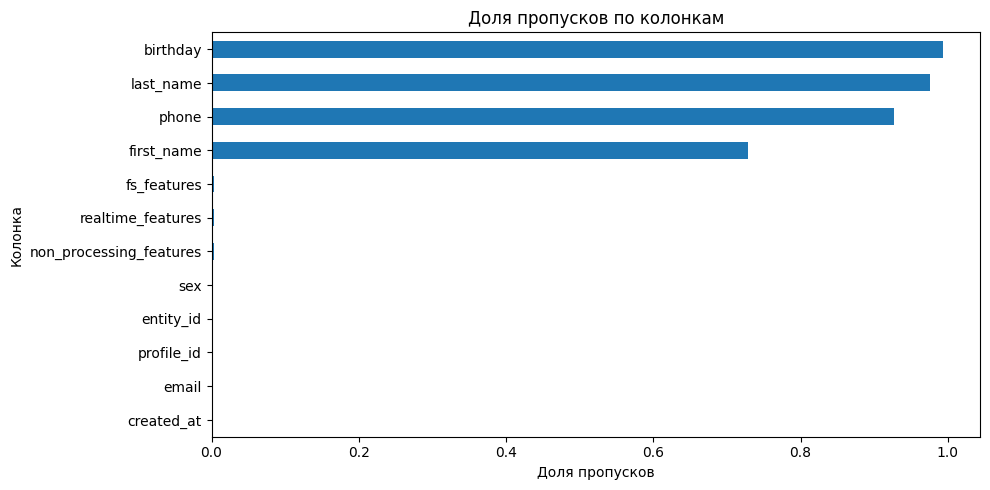

In [7]:
plt.figure(figsize=(10, 5))
missing_summary["missing_share"].sort_values().plot(kind="barh")
plt.title("Доля пропусков по колонкам")
plt.xlabel("Доля пропусков")
plt.ylabel("Колонка")
plt.tight_layout()
plt.show()

### Выводы по этапу

- В данных высокая неполнота персональных полей: `birthday`, `last_name`, `phone` и `first_name` заполнены существенно хуже, чем `email`.
- Это означает, что простые правила вида «совпали ФИО + дата рождения» будут иметь низкое покрытие и не смогут стать основной стратегией поиска дублей.

## 5. Проверка ключей `profile_id` и `entity_id`

In [8]:
key_summary = pd.DataFrame({
    "metric": [
        "rows",
        "unique_profile_id",
        "unique_entity_id",
        "unique_email",
    ],
    "value": [
        len(df),
        df["profile_id"].nunique(dropna=False) if "profile_id" in df.columns else np.nan,
        df["entity_id"].nunique(dropna=False) if "entity_id" in df.columns else np.nan,
        df["email"].nunique(dropna=False) if "email" in df.columns else np.nan,
    ]
})

display(key_summary)

,metric,value
0,rows,68036
1,unique_profile_id,61927
2,unique_entity_id,53369
3,unique_email,61927


In [9]:
profile_entity_counts = (
    df.groupby("profile_id")["entity_id"]
    .nunique(dropna=False)
    .reset_index(name="n_unique_entity_id")
)

print("Распределение количества entity_id на один profile_id:")
display(profile_entity_counts["n_unique_entity_id"].value_counts().sort_index().to_frame("n_profile_id"))

bad_profiles = profile_entity_counts[profile_entity_counts["n_unique_entity_id"] > 1]
print(f"profile_id, связанных более чем с одним entity_id: {len(bad_profiles):,}")

Распределение количества entity_id на один profile_id:


,n_profile_id
n_unique_entity_id,
1,61927


profile_id, связанных более чем с одним entity_id: 0


In [10]:
entity_profile_counts_row_level = (
    df.groupby("entity_id")["profile_id"]
    .nunique(dropna=False)
    .reset_index(name="n_unique_profile_id")
)

print("Распределение количества profile_id на один entity_id:")
display(
    entity_profile_counts_row_level["n_unique_profile_id"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"n_unique_profile_id": "cluster_size", "count": "n_entity_id"})
    .head(30)
)

n_duplicate_entities = int((entity_profile_counts_row_level["n_unique_profile_id"] > 1).sum())
print(f"Entity_id с несколькими profile_id: {n_duplicate_entities:,}")

Распределение количества profile_id на один entity_id:


,cluster_size,n_entity_id
0,1,45296
1,2,7808
2,3,227
3,4,26
4,5,4
5,6,3
6,7,1
7,10,1
8,22,1
9,37,1


Entity_id с несколькими profile_id: 8,073


### Выводы по этапу

- В файле **61 927 уникальных `profile_id`** и **53 369 уникальных `entity_id`**.
- Обратная связь не является один-к-одному: один `entity_id` может включать несколько `profile_id`.
- `email` уникален на уровне `profile_id`: точное совпадение полного email не является полезным способом поиска дублей между разными профилями.


## 6. Повторные строки одного `profile_id`

Перед решением Entity Resolution нужно разделить два явления:

1. повторные строки одного и того же `profile_id`;
2. разные `profile_id`, относящиеся к одному `entity_id`.

Для модели объединения клиентов основной объект — профиль, поэтому ниже мы агрегируем строки до уровня `profile_id`.

,count,mean,std,min,25%,50%,75%,max
n_rows,61927.0,1.098648,0.539293,1.0,1.0,1.0,1.0,29.0


profile_id, встречающихся более одного раза: 3,705
Максимальное число строк на один profile_id: 29


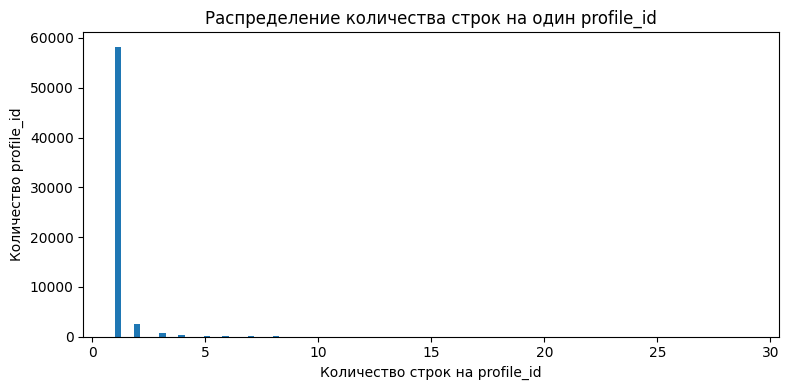

In [11]:
rows_per_profile = df.groupby("profile_id").size().rename("n_rows").reset_index()

display(rows_per_profile["n_rows"].describe().to_frame().T)
print(f"profile_id, встречающихся более одного раза: {(rows_per_profile['n_rows'] > 1).sum():,}")
print(f"Максимальное число строк на один profile_id: {rows_per_profile['n_rows'].max():,}")

plt.figure(figsize=(8, 4))
rows_per_profile["n_rows"].clip(upper=100).plot(kind="hist", bins=100)
plt.title("Распределение количества строк на один profile_id")
plt.xlabel("Количество строк на profile_id")
plt.ylabel("Количество profile_id")
plt.tight_layout()
plt.show()

### Выводы по этапу

- В исходном файле строк больше, чем уникальных профилей: **68 036 строк против 61 927 `profile_id`**.
- **3 705 профилей** встречаются более одного раза; максимальное число строк на один профиль — **29**.
- Эти повторения не следует смешивать с duplicate-профилями. Вероятнее всего, это повторные наблюдения, события, визиты, обновления или снапшоты одного и того же профиля.


## 7. Агрегация до уровня профиля

Создаем `profile_df`, где одна строка соответствует одному `profile_id`.

In [14]:
def is_empty_value(x):
    """Проверяет пустые значения, включая None, NaN, пустые строки и пустые массивы/списки."""
    if x is None:
        return True
    if isinstance(x, float) and np.isnan(x):
        return True
    if isinstance(x, str) and x.strip() == "":
        return True
    if isinstance(x, np.ndarray) and len(x) == 0:
        return True
    if isinstance(x, (list, tuple, set)) and len(x) == 0:
        return True
    return False

def to_hashable(x):
    if is_empty_value(x):
        return None
    if isinstance(x, (list, tuple, np.ndarray)):
        if isinstance(x, np.ndarray):
            x = x.tolist()
        return tuple(to_hashable(item) for item in x)
    if isinstance(x, dict):
        return tuple(sorted((k, to_hashable(v)) for k, v in x.items()))
    return x

def first_non_empty(series):
    for x in series:
        if not is_empty_value(x):
            return x
    return np.nan

def unique_non_empty_count(series):
    values = []
    for x in series:
        if not is_empty_value(x):
            values.append(to_hashable(x))
    return len(set(values))

def listify(x):
    if is_empty_value(x):
        return []
    if isinstance(x, np.ndarray):
        return list(x.tolist())
    if isinstance(x, (list, tuple, set)):
        return list(x)
    return [x]

def merge_unique_lists(series):
    result = []
    seen = set()
    for item in series:
        for token in listify(item):
            if is_empty_value(token):
                continue
            token = str(token)
            if token not in seen:
                seen.add(token)
                result.append(token)
    return result

In [15]:
profile_df = (
    df.groupby("profile_id", as_index=False)
      .agg(
          entity_id=("entity_id", first_non_empty),
          n_rows_per_profile=("profile_id", "size"),
          first_seen_at=("created_at", "min"),
          last_seen_at=("created_at", "max"),
          first_name=("first_name", first_non_empty),
          last_name=("last_name", first_non_empty),
          email=("email", first_non_empty),
          phone=("phone", first_non_empty),
          birthday=("birthday", first_non_empty),
          sex=("sex", first_non_empty),
          n_unique_first_name=("first_name", unique_non_empty_count),
          n_unique_last_name=("last_name", unique_non_empty_count),
          n_unique_email=("email", unique_non_empty_count),
          n_unique_phone=("phone", unique_non_empty_count),
          n_unique_birthday=("birthday", unique_non_empty_count),
          n_unique_sex=("sex", unique_non_empty_count),
          realtime_features=("realtime_features", first_non_empty),
          n_unique_realtime_features=("realtime_features", unique_non_empty_count),
          non_processing_features=("non_processing_features", merge_unique_lists),
          fs_features=("fs_features", merge_unique_lists),
      )
)

profile_df["profile_lifetime_days"] = (
    profile_df["last_seen_at"] - profile_df["first_seen_at"]
).dt.total_seconds() / 86400

print(f"Исходная таблица: {df.shape[0]:,} строк")
print(f"Profile-level таблица: {profile_df.shape[0]:,} строк")
print(f"Уникальных profile_id в исходных данных: {df['profile_id'].nunique():,}")

assert len(profile_df) == df["profile_id"].nunique(), "Ошибка агрегации: число строк не равно числу уникальных profile_id"

display(profile_df.head())

Исходная таблица: 68,036 строк
Profile-level таблица: 61,927 строк
Уникальных profile_id в исходных данных: 61,927


,profile_id,entity_id,n_rows_per_profile,first_seen_at,last_seen_at,first_name,last_name,email,phone,birthday,sex,n_unique_first_name,n_unique_last_name,n_unique_email,n_unique_phone,n_unique_birthday,n_unique_sex,realtime_features,n_unique_realtime_features,non_processing_features,fs_features,profile_lifetime_days
0,000163e0-b9b4-3323-84ea-6495df7fe895,266eb686284a35db45a797ef75c01fc276e71fee1eb2aaaf71d3606a64b91aeb,1,2026-05-09 07:47:48.739,2026-05-09 07:47:48.739,NaN,NaN,srnxztxqa8004@gmail.com,NaN,NaT,unknown,0,0,1,0,1,1,"{""country"":""BY"",""is_million"":true,""visit_count"":""0"",""tz_offset"":3,""geoname"":""Minsk"",""geoid"":625144,""local_hour"":10,""day"":5,""population"":1742124}",1,"[geoname_id:625144, subdivision_1_iso_code:HM, is_not_russia, browser:chrome, device:smartphone, osfamily:android]",[],0.0
1,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,ef07a5be121a62611f6b1f7e25fed25a0d02b9571d7bbcfb0370ff164dd1bbd4,1,2026-01-26 13:13:07.558,2026-01-26 13:13:07.558,NaN,NaN,wjpfhmp@vk.com,79959678942,NaT,unknown,0,0,1,1,1,1,{},1,"[device:smartphone, is_not_russia, osfamily:ios]","[mm_event_90:sent, mm_event_30:sent, postman_campaign_30:workflow, has_click_365:3827, source_site_365:6329, has_accept_365:3827, postman_action_90:smtp_lin...",0.0
2,0002ac9a-fd3f-31a7-9ab5-77b1d3961382,244363f995686f034394129500ab9c06fa262eefa04cfc1c3bb554f1227f2f9c,1,2026-03-06 15:45:40.523,2026-03-06 15:45:40.523,Василиса,NaN,qleopvd052996@gmail.com,NaN,NaT,unknown,1,0,1,0,1,1,{},1,"[osfamily:android, subdivision_1_iso_code:KR, device:smartphone, browser:chrome]",[source_site_365:6976],0.0
3,00036d8f-9320-39b0-96e9-f0a457fc82a4,5b3e5b68690777e70e9f394d45ebb85aeb5f12c68b2f0656e2ca6358a8a01eb8,1,2026-04-01 22:57:18.942,2026-04-01 22:57:18.942,NaN,NaN,hxubxrhcy67@inbox.ru,NaN,NaT,unknown,0,0,1,0,1,1,"{""country"":""RU"",""is_million"":false,""visit_count"":""21"",""tz_offset"":3,""geoname"":""Kursk"",""geoid"":538560,""local_hour"":1,""day"":3,""population"":448733}",1,"[osfamily:android, subdivision_1_iso_code:KRS, browser:chrome, device:smartphone, geoname_id:538560]","[has_accept_30:6592, has_view_90:5553, has_view_90:6592, has_view_90:3756, has_view_90:6980, has_view_90:6780, visited_30:1345, has_view_90:6914, has_accoun...",0.0
4,0003e46e-fc6c-34a8-8358-606d66c1eec2,eb99135fb3e4af6723c6daf1ac22f4f9c15218c3f17a5324daef53e70032a8da,1,2026-02-10 13:34:15.506,2026-02-10 13:34:15.506,NaN,NaN,lxhsidqbzwloh588@gmail.com,NaN,NaT,unknown,0,0,1,0,1,1,"{""country"":""UZ"",""is_million"":true,""tz_offset"":5,""geoname"":""Tashkent"",""geoid"":1512569,""local_hour"":18,""day"":1,""population"":1978028}",1,"[browser:chrome, osfamily:android, device:smartphone, geoname_id:1512569, is_not_russia, subdivision_1_iso_code:TK]",[],0.0


### Выводы по этапу

- `entity_id` сохраняется как целевая разметка, а `created_at` агрегируется в `first_seen_at` и `last_seen_at`, чтобы сохранить временной контекст появления профиля.
- Для списочных признаков (`non_processing_features`, `fs_features`) корректнее не брать первое значение, а объединять уникальные токены внутри профиля.


## 8. Обогащение `profile_df`: нормализация полей и признаки полноты

In [16]:
def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x if x else np.nan


def email_local_part(email):
    if pd.isna(email):
        return np.nan
    email = str(email).strip().lower()
    if "@" not in email:
        return np.nan
    return email.split("@", 1)[0]


def email_domain(email):
    if pd.isna(email):
        return np.nan
    email = str(email).strip().lower()
    if "@" not in email:
        return np.nan
    return email.split("@", 1)[1]


def normalize_phone(phone):
    if pd.isna(phone):
        return np.nan
    digits = re.sub(r"\D", "", str(phone))
    if len(digits) == 11 and digits.startswith("8"):
        digits = "7" + digits[1:]
    return digits if digits else np.nan


def safe_birth_year(x):
    if pd.isna(x):
        return np.nan
    try:
        return pd.to_datetime(x).year
    except Exception:
        return np.nan

profile_df["first_name_norm"] = profile_df["first_name"].map(normalize_text)
profile_df["last_name_norm"] = profile_df["last_name"].map(normalize_text)
profile_df["email_norm"] = profile_df["email"].astype(str).str.strip().str.lower()
profile_df["email_local"] = profile_df["email"].map(email_local_part)
profile_df["email_domain"] = profile_df["email"].map(email_domain)
profile_df["phone_norm"] = profile_df["phone"].map(normalize_phone)
profile_df["birth_year"] = profile_df["birthday"].map(safe_birth_year)
profile_df["sex_norm"] = profile_df["sex"].map(normalize_text)

profile_df["has_first_name"] = profile_df["first_name_norm"].notna()
profile_df["has_last_name"] = profile_df["last_name_norm"].notna()
profile_df["has_email"] = profile_df["email_norm"].notna()
profile_df["has_phone"] = profile_df["phone_norm"].notna()
profile_df["has_birthday"] = profile_df["birth_year"].notna()
profile_df["has_known_sex"] = profile_df["sex_norm"].notna() & ~profile_df["sex_norm"].isin(["unknown", "none", "nan"])

identity_presence_cols = [
    "has_first_name",
    "has_last_name",
    "has_email",
    "has_phone",
    "has_birthday",
    "has_known_sex",
]

profile_df["identity_completeness_score"] = profile_df[identity_presence_cols].sum(axis=1)

entity_profile_counts = profile_df.groupby("entity_id")["profile_id"].nunique().rename("n_profiles_in_entity")
profile_df = profile_df.merge(entity_profile_counts, on="entity_id", how="left")
profile_df["is_duplicate_entity"] = profile_df["n_profiles_in_entity"] > 1

profile_df[[
    "profile_id", "entity_id", "first_seen_at", "email", "email_domain", "phone_norm",
    "identity_completeness_score", "n_profiles_in_entity", "is_duplicate_entity"
]].head()

,profile_id,entity_id,first_seen_at,email,email_domain,phone_norm,identity_completeness_score,n_profiles_in_entity,is_duplicate_entity
0,000163e0-b9b4-3323-84ea-6495df7fe895,266eb686284a35db45a797ef75c01fc276e71fee1eb2aaaf71d3606a64b91aeb,2026-05-09 07:47:48.739,srnxztxqa8004@gmail.com,gmail.com,NaN,1,1,False
1,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,ef07a5be121a62611f6b1f7e25fed25a0d02b9571d7bbcfb0370ff164dd1bbd4,2026-01-26 13:13:07.558,wjpfhmp@vk.com,vk.com,79959678942,2,1,False
2,0002ac9a-fd3f-31a7-9ab5-77b1d3961382,244363f995686f034394129500ab9c06fa262eefa04cfc1c3bb554f1227f2f9c,2026-03-06 15:45:40.523,qleopvd052996@gmail.com,gmail.com,NaN,2,1,False
3,00036d8f-9320-39b0-96e9-f0a457fc82a4,5b3e5b68690777e70e9f394d45ebb85aeb5f12c68b2f0656e2ca6358a8a01eb8,2026-04-01 22:57:18.942,hxubxrhcy67@inbox.ru,inbox.ru,NaN,1,1,False
4,0003e46e-fc6c-34a8-8358-606d66c1eec2,eb99135fb3e4af6723c6daf1ac22f4f9c15218c3f17a5324daef53e70032a8da,2026-02-10 13:34:15.506,lxhsidqbzwloh588@gmail.com,gmail.com,NaN,1,1,False


### Выводы по этапу

- email было разложено на `local-part` и домен, телефон приведен к единому числовому формату, текстовые поля очищены от регистра и лишних пробелов.
- Для пола важно отделить `unknown` от реальных значений `male`/`female`: совпадение `unknown == unknown` не должно считаться сильным положительным сигналом.
- `identity_completeness_score` нужен как потенциальный предиктор вероятности дублирования.
- В модели полезно использовать не только сами значения полей, но и флаги их наличия: `has_phone`, `has_first_name`, `has_birthday`, `has_known_sex` и т.д.


## 9. Profile-level пропуски и полнота профилей

In [17]:
profile_missing_summary = (
    pd.DataFrame({
        "missing_count": profile_df.isna().sum(),
        "missing_share": profile_df.isna().mean(),
        "non_missing_count": profile_df.notna().sum(),
    })
    .sort_values("missing_share", ascending=False)
)

display(profile_missing_summary.head(30).style.format({"missing_share": "{:.2%}"}))

,missing_count,missing_share,non_missing_count
birthday,61558,99.40%,369
birth_year,61558,99.40%,369
last_name,60440,97.60%,1487
last_name_norm,60440,97.60%,1487
phone_norm,57271,92.48%,4656
phone,57271,92.48%,4656
first_name_norm,44885,72.48%,17042
first_name,44885,72.48%,17042
realtime_features,215,0.35%,61712
sex_norm,47,0.08%,61880


,identity_completeness_score,n_profiles,duplicate_rate,n_duplicate_profiles
0,1,39439,31.00%,12228
1,2,7413,23.28%,1726
2,3,12205,18.07%,2205
3,4,2470,16.68%,412
4,5,361,14.96%,54
5,6,39,15.38%,6


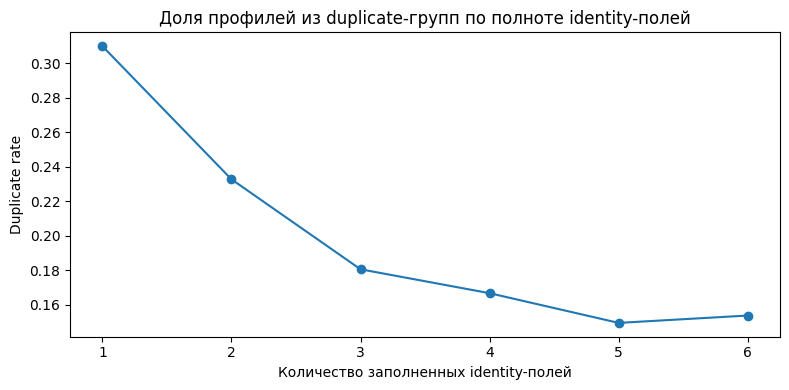

In [18]:
completeness_summary = (
    profile_df.groupby("identity_completeness_score")
    .agg(
        n_profiles=("profile_id", "size"),
        duplicate_rate=("is_duplicate_entity", "mean"),
        n_duplicate_profiles=("is_duplicate_entity", "sum"),
    )
    .reset_index()
)

display(completeness_summary.style.format({"duplicate_rate": "{:.2%}"}))

plt.figure(figsize=(8, 4))
plt.plot(completeness_summary["identity_completeness_score"], completeness_summary["duplicate_rate"], marker="o")
plt.title("Доля профилей из duplicate-групп по полноте identity-полей")
plt.xlabel("Количество заполненных identity-полей")
plt.ylabel("Duplicate rate")
plt.tight_layout()
plt.show()

### Выводы по этапу

- На уровне профилей `birthday` отсутствует примерно у **99,4%**, `last_name` — у **97,6%**, `phone` — у **92,5%**, `first_name` — у **72,5%** профилей.
- `email` заполнен у всех профилей, но полное значение email уникально для каждого `profile_id`.
- Профили с меньшей полнотой identity-полей имеют более высокий duplicate rate: для профилей с минимальной полнотой он около **31%**, а для более заполненных профилей заметно ниже.
- **Это подтверждает важный паттерн: дубли чаще возникают у неполных, слабо идентифицируемых профилей.**


## 10. Размеры истинных duplicate-кластеров

Если у одного `entity_id` несколько `profile_id`, значит эти профили относятся к одному реальному клиенту.

In [19]:
cluster_size_distribution = (
    profile_df[["entity_id", "n_profiles_in_entity"]]
    .drop_duplicates()
    ["n_profiles_in_entity"]
    .value_counts()
    .sort_index()
    .reset_index()
)
cluster_size_distribution.columns = ["cluster_size", "n_entities"]

display(cluster_size_distribution.head(30))

n_entities = profile_df["entity_id"].nunique()
n_duplicate_entities = int((cluster_size_distribution.loc[cluster_size_distribution["cluster_size"] > 1, "n_entities"]).sum())
n_profiles_in_duplicate_entities = int(profile_df["is_duplicate_entity"].sum())

print(f"Всего entity_id: {n_entities:,}")
print(f"Entity_id с несколькими profile_id: {n_duplicate_entities:,}")
print(f"Профилей, входящих в duplicate-группы: {n_profiles_in_duplicate_entities:,}")
print(f"Доля профилей в duplicate-группах: {profile_df['is_duplicate_entity'].mean():.2%}")
print(f"Максимальный размер кластера: {profile_df['n_profiles_in_entity'].max():,}")

,cluster_size,n_entities
0,1,45296
1,2,7808
2,3,227
3,4,26
4,5,4
5,6,3
6,7,1
7,10,1
8,22,1
9,37,1


Всего entity_id: 53,369
Entity_id с несколькими profile_id: 8,073
Профилей, входящих в duplicate-группы: 16,631
Доля профилей в duplicate-группах: 26.86%
Максимальный размер кластера: 116


<Figure size 1000x400 with 0 Axes>

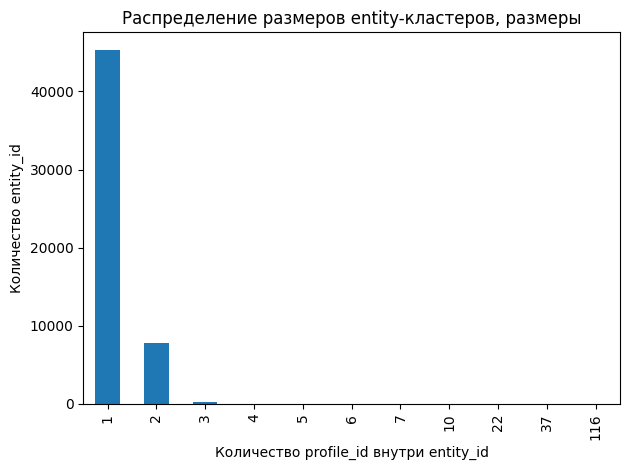

In [20]:
plt.figure(figsize=(10, 4))
cluster_size_distribution[cluster_size_distribution["cluster_size"] <= 1000].plot(
    x="cluster_size", y="n_entities", kind="bar", legend=False
)
plt.title("Распределение размеров entity-кластеров, размеры")
plt.xlabel("Количество profile_id внутри entity_id")
plt.ylabel("Количество entity_id")
plt.tight_layout()
plt.show()

### Выводы по этапу

- В данных **8 073 `entity_id`** имеют больше одного `profile_id`; это размеченные duplicate-группы.
- В duplicate-группы входит **16 631 профиль**, то есть **26,86%** всех профилей.
- Большинство duplicate-кластеров имеют размер 2, но есть крупные кластеры; максимальный размер — **116 профилей** на один `entity_id`.

## 11. Анализ стабильности полей внутри duplicate-групп

Проверяем, какие поля меняются внутри одного `entity_id`. Это помогает понять, какие признаки являются стабильными идентификаторами, а какие часто отличаются у дублей.

In [21]:
def nunique_non_missing(s):
    return s.dropna().nunique()

fields_to_check = [
    "email", "email_domain", "email_local", "phone_norm", "first_name_norm", "last_name_norm", "birth_year", "sex_norm"
]

duplicate_profiles = profile_df[profile_df["is_duplicate_entity"]].copy()

variation_rows = []
for col in fields_to_check:
    nun = duplicate_profiles.groupby("entity_id")[col].apply(nunique_non_missing)
    variation_rows.append({
        "field": col,
        "duplicate_groups": len(nun),
        "groups_with_0_non_missing_values": int((nun == 0).sum()),
        "groups_with_1_non_missing_value": int((nun == 1).sum()),
        "groups_with_2plus_values": int((nun > 1).sum()),
        "share_groups_with_2plus_values": float((nun > 1).mean()),
        "share_groups_with_0_values": float((nun == 0).mean()),
    })

variation_summary = pd.DataFrame(variation_rows).sort_values("share_groups_with_2plus_values", ascending=False)
display(variation_summary.style.format({
    "share_groups_with_2plus_values": "{:.2%}",
    "share_groups_with_0_values": "{:.2%}",
}))

,field,duplicate_groups,groups_with_0_non_missing_values,groups_with_1_non_missing_value,groups_with_2plus_values,share_groups_with_2plus_values,share_groups_with_0_values
0,email,8073,0,0,8073,100.00%,0.00%
2,email_local,8073,0,0,8073,100.00%,0.00%
1,email_domain,8073,0,3778,4295,53.20%,0.00%
7,sex_norm,8073,3,5755,2315,28.68%,0.04%
4,first_name_norm,8073,5409,2430,234,2.90%,67.00%
3,phone_norm,8073,7395,627,51,0.63%,91.60%
5,last_name_norm,8073,7776,291,6,0.07%,96.32%
6,birth_year,8073,8003,70,0,0.00%,99.13%


### Выводы по этапу

- Во всех duplicate-группах различаются полные email, поэтому exact-match по email не решает задачу.
- `phone`, `birthday` и `last_name` редко варьируются внутри duplicate-групп, но это в основном связано с их низкой заполненностью.
- `sex` отличается или меняется по информативности примерно в значимой доле duplicate-групп.


## 12. Email-анализ

В этом датасете email может быть уникален на уровне профиля, поэтому exact-match по email может не находить дубли. Вместо этого email полезен как источник производных признаков: домен, local-part, наличие цифр, длина, разделители и похожесть local-part.

In [22]:
email_summary = pd.DataFrame({
    "metric": [
        "profiles",
        "unique_email",
        "unique_email_domain",
        "email_missing_share",
    ],
    "value": [
        len(profile_df),
        profile_df["email_norm"].nunique(dropna=False),
        profile_df["email_domain"].nunique(dropna=False),
        profile_df["email_norm"].isna().mean(),
    ]
})

display(email_summary)

email_profile_counts = profile_df.groupby("email_norm")["profile_id"].nunique().sort_values(ascending=False)
print("Максимальное число profile_id на один email:", int(email_profile_counts.max()))
print("Email, встречающихся у нескольких profile_id:", int((email_profile_counts > 1).sum()))

,metric,value
0,profiles,61927.0
1,unique_email,61927.0
2,unique_email_domain,780.0
3,email_missing_share,0.0


Максимальное число profile_id на один email: 1
Email, встречающихся у нескольких profile_id: 0


,email_domain,n_profiles
0,gmail.com,31253
1,mail.ru,15314
2,yandex.ru,7416
3,icloud.com,1556
4,bk.ru,1492
5,list.ru,741
6,inbox.ru,676
7,rambler.ru,453
8,internet.ru,313
9,ya.ru,308


<Figure size 900x500 with 0 Axes>

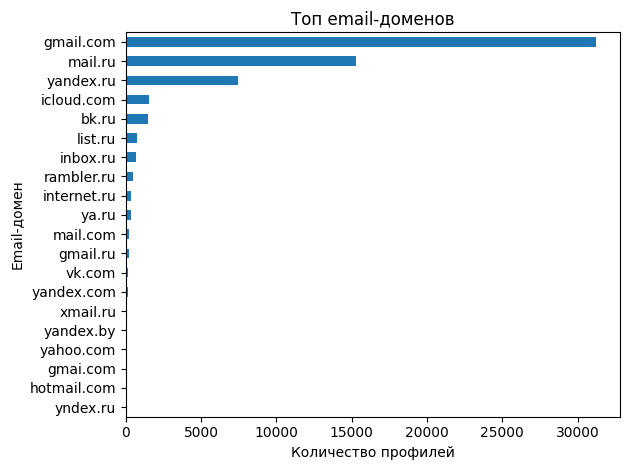

In [23]:
top_domains = profile_df["email_domain"].value_counts(dropna=False).head(20).reset_index()
top_domains.columns = ["email_domain", "n_profiles"]
display(top_domains)

plt.figure(figsize=(9, 5))
top_domains.sort_values("n_profiles").plot(x="email_domain", y="n_profiles", kind="barh", legend=False)
plt.title("Топ email-доменов")
plt.xlabel("Количество профилей")
plt.ylabel("Email-домен")
plt.tight_layout()
plt.show()

In [24]:
email_domain_dup_rate = (
    profile_df.groupby("email_domain")
    .agg(
        n_profiles=("profile_id", "size"),
        duplicate_rate=("is_duplicate_entity", "mean"),
        n_duplicate_profiles=("is_duplicate_entity", "sum"),
    )
    .query("n_profiles >= 100")
    .sort_values("duplicate_rate", ascending=False)
)

display(email_domain_dup_rate.head(20).style.format({"duplicate_rate": "{:.2%}"}))

,n_profiles,duplicate_rate,n_duplicate_profiles
email_domain,,,
gmail.ru,203,54.19%,110
yandex.com,116,52.59%,61
ya.ru,308,45.78%,141
mail.com,211,43.13%,91
yandex.ru,7416,30.93%,2294
internet.ru,313,29.07%,91
vk.com,119,28.57%,34
icloud.com,1556,27.51%,428
gmail.com,31253,26.38%,8246


In [25]:
email_domains_per_entity = (
    duplicate_profiles.groupby("entity_id")["email_domain"]
    .nunique(dropna=True)
    .rename("n_email_domains")
    .reset_index()
)

display(email_domains_per_entity["n_email_domains"].value_counts().sort_index().to_frame("n_entities"))
print("Доля duplicate-групп с более чем одним email-доменом:", (email_domains_per_entity["n_email_domains"] > 1).mean())

,n_entities
n_email_domains,
1,3778
2,4237
3,55
4,2
5,1


Доля duplicate-групп с более чем одним email-доменом: 0.5320203146290102


### Выводы по этапу

- Полный email уникален для `profile_id`, поэтому поиск дублей по точному совпадению email практически бесполезен.
- Основная ценность email — в производных признаках: домен, группа домена, похожесть `local-part`, наличие цифр, разделителей, длина local-part, совпадение или близость шаблонов.
- Отдельно стоит проверять пары вроде `gmail.com` vs `googlemail.com`, `yandex.ru` vs `ya.ru`.


## 13. Телефон

Телефон часто является сильным идентификатором, но в зашумленных клиентских базах может иметь низкое покрытие. Проверяем заполненность, повторяемость и пересечение между `entity_id`.

In [26]:
phone_stats = pd.DataFrame({
    "metric": [
        "profiles",
        "profiles_with_phone",
        "phone_coverage",
        "unique_phone",
        "phones_used_by_multiple_profiles",
    ],
    "value": [
        len(profile_df),
        int(profile_df["phone_norm"].notna().sum()),
        profile_df["phone_norm"].notna().mean(),
        profile_df["phone_norm"].nunique(dropna=True),
        int((profile_df.groupby("phone_norm")["profile_id"].nunique() > 1).sum()),
    ]
})

display(phone_stats)

,metric,value
0,profiles,61927.000000
1,profiles_with_phone,4656.000000
2,phone_coverage,0.075185
3,unique_phone,4578.000000
4,phones_used_by_multiple_profiles,78.000000


In [27]:
phone_entity_counts = (
    profile_df.dropna(subset=["phone_norm"])
    .groupby("phone_norm")["entity_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Максимальное число entity_id на один phone_norm:", int(phone_entity_counts.max()) if len(phone_entity_counts) else 0)
print("Телефонов, связанных с несколькими entity_id:", int((phone_entity_counts > 1).sum()) if len(phone_entity_counts) else 0)

display(phone_entity_counts.head(10).to_frame("n_entity_id"))

Максимальное число entity_id на один phone_norm: 1
Телефонов, связанных с несколькими entity_id: 0


,n_entity_id
phone_norm,
77003500958,1
79522267548,1
79522576316,1
79522500880,1
79522488031,1
79522407215,1
79522365908,1
79522328418,1
79522258619,1


### Выводы по этапу

- Один и тот же телефон не пересекает разные `entity_id`, что делает совпадение нормализованного телефона потенциально очень точным сигналом.
- Телефон подходит как высокоточный сигнал совпадения, но не может быть единственной основой отбора похожих профилей из-за большого количества пропусков.
- Для телефона нужно использовать нормализацию и exact-match; Levenshtein для телефонных номеров не нужен.


## 14. ФИО, пол и дата рождения

,field,coverage
5,email,100.00%
4,known_sex,27.97%
0,first_name,27.52%
2,phone,7.52%
1,last_name,2.40%
3,birthday,0.60%


<Figure size 800x400 with 0 Axes>

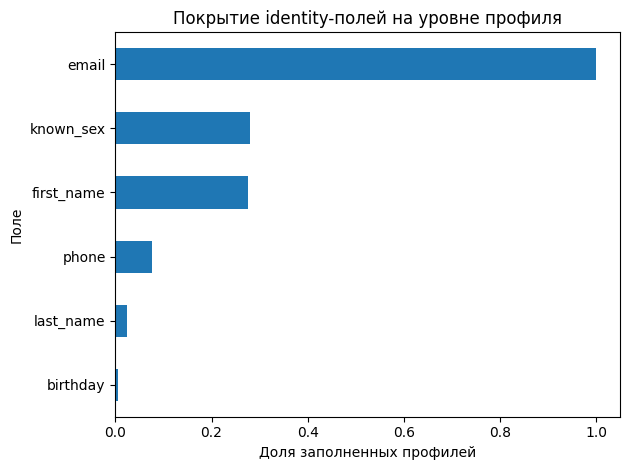

In [28]:
identity_field_coverage = pd.DataFrame({
    "field": ["first_name", "last_name", "phone", "birthday", "known_sex", "email"],
    "coverage": [
        profile_df["has_first_name"].mean(),
        profile_df["has_last_name"].mean(),
        profile_df["has_phone"].mean(),
        profile_df["has_birthday"].mean(),
        profile_df["has_known_sex"].mean(),
        profile_df["has_email"].mean(),
    ]
}).sort_values("coverage", ascending=False)

display(identity_field_coverage.style.format({"coverage": "{:.2%}"}))

plt.figure(figsize=(8, 4))
identity_field_coverage.sort_values("coverage").plot(x="field", y="coverage", kind="barh", legend=False)
plt.title("Покрытие identity-полей на уровне профиля")
plt.xlabel("Доля заполненных профилей")
plt.ylabel("Поле")
plt.tight_layout()
plt.show()

In [29]:
print("Распределение sex_norm:")
display(profile_df["sex_norm"].fillna("<missing>").value_counts(dropna=False).to_frame("n_profiles"))

print("Топ first_name_norm:")
display(profile_df["first_name_norm"].value_counts().head(20).to_frame("n_profiles"))

print("Топ last_name_norm:")
display(profile_df["last_name_norm"].value_counts().head(20).to_frame("n_profiles"))

Распределение sex_norm:


,n_profiles
sex_norm,
unknown,44562
female,9170
male,8148
<missing>,47


Топ first_name_norm:


,n_profiles
first_name_norm,
артём,1542
алевтина,1428
александр,1201
зоя,1119
василиса,857
елизавета,728
егор,587
кира,562
георгий,522


Топ last_name_norm:


,n_profiles
last_name_norm,
гусева,13
владимиров,11
симонова,10
третьяков,9
котова,9
иванова,9
архипова,9
уварова,8
селезнева,8


### Выводы по этапу

- ФИО и дата рождения не могут быть основным способом поиска дублей, но могут давать сильные дополнительные сигналы, когда заполнены.
- `sex` имеет значение `unknown` примерно у **72%** профилей; совпадение двух `unknown` почти неинформативно, а конфликт известных значений пола может быть отрицательным сигналом.


## 15. Временные паттерны появления дублей

Анализируем, когда появляются профили, входящие в duplicate-группы, и сколько времени проходит между первым и последним профилем внутри одного `entity_id`.

In [30]:
profile_df["first_seen_date"] = profile_df["first_seen_at"].dt.date
profile_df["first_seen_hour"] = profile_df["first_seen_at"].dt.hour
profile_df["first_seen_weekday"] = profile_df["first_seen_at"].dt.day_name()

created_daily = (
    profile_df.groupby("first_seen_date")
    .agg(
        n_profiles=("profile_id", "size"),
        duplicate_rate=("is_duplicate_entity", "mean"),
        n_duplicate_profiles=("is_duplicate_entity", "sum"),
    )
    .reset_index()
)

display(created_daily.head())

,first_seen_date,n_profiles,duplicate_rate,n_duplicate_profiles
0,2025-11-01,378,0.246032,93
1,2025-11-02,326,0.260736,85
2,2025-11-03,289,0.252595,73
3,2025-11-04,245,0.318367,78
4,2025-11-05,266,0.274436,73


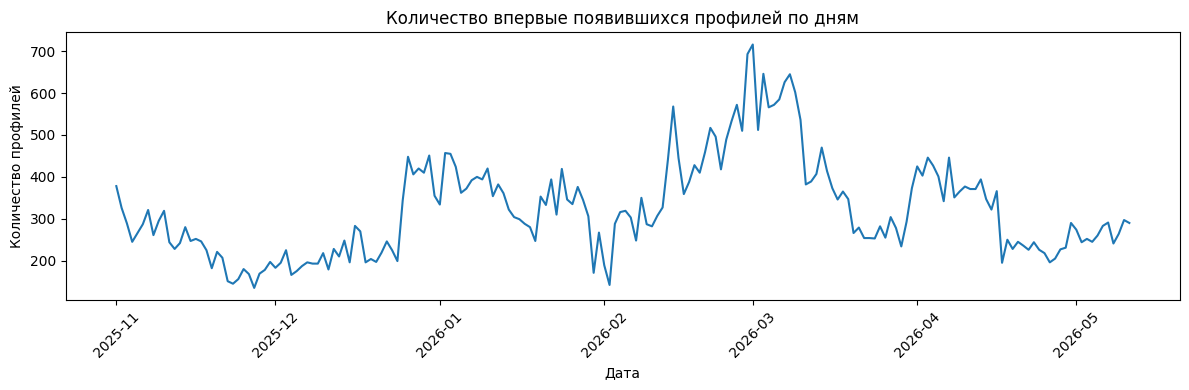

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(created_daily["first_seen_date"], created_daily["n_profiles"])
plt.title("Количество впервые появившихся профилей по дням")
plt.xlabel("Дата")
plt.ylabel("Количество профилей")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

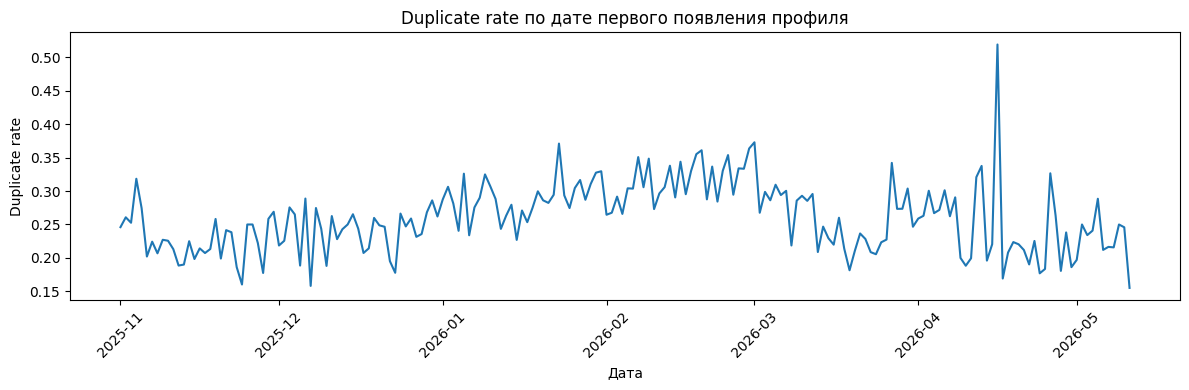

In [32]:
plt.figure(figsize=(12, 4))
plt.plot(created_daily["first_seen_date"], created_daily["duplicate_rate"])
plt.title("Duplicate rate по дате первого появления профиля")
plt.xlabel("Дата")
plt.ylabel("Duplicate rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
span_days,8073.0,31.564068,38.505079,0.000177,0.00362,15.497145,53.280281,187.359589


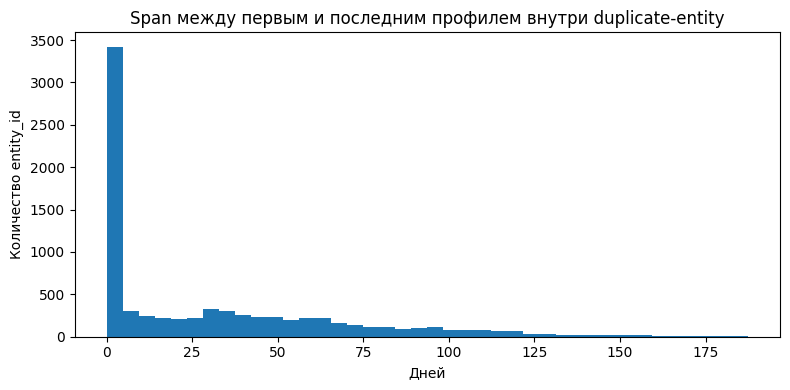

In [33]:
entity_time_span = (
    profile_df.groupby("entity_id")
    .agg(
        n_profiles=("profile_id", "nunique"),
        first_profile_seen=("first_seen_at", "min"),
        last_profile_seen=("first_seen_at", "max"),
    )
)
entity_time_span["span_days"] = (
    entity_time_span["last_profile_seen"] - entity_time_span["first_profile_seen"]
).dt.total_seconds() / 86400

entity_time_span_dup = entity_time_span[entity_time_span["n_profiles"] > 1]

display(entity_time_span_dup["span_days"].describe().to_frame().T)

plt.figure(figsize=(8, 4))
entity_time_span_dup["span_days"].clip(upper=1000).plot(kind="hist", bins=40)
plt.title("Span между первым и последним профилем внутри duplicate-entity")
plt.xlabel("Дней")
plt.ylabel("Количество entity_id")
plt.tight_layout()
plt.show()

### Выводы по этапу

- Четверть duplicate-групп возникает почти одновременно, а часть групп растягивается на месяцы; это указывает на разные механизмы появления дублей.


## 16. Разбор `realtime_features`

`realtime_features` хранится как JSON-строка или словарь. Распарсим его в отдельные признаки: страна, город, geoid, часовой пояс, локальный час, население и т.д.

In [34]:
def parse_realtime(x):
    if is_empty_value(x):
        return {}
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return parsed if isinstance(parsed, dict) else {}
        except Exception:
            return {}
    return {}

realtime_dicts = profile_df["realtime_features"].map(parse_realtime)
realtime_df = pd.json_normalize(realtime_dicts).add_prefix("rt_")

profile_df = pd.concat([profile_df.reset_index(drop=True), realtime_df.reset_index(drop=True)], axis=1)

print("Распарсенные realtime-колонки:")
print([c for c in profile_df.columns if c.startswith("rt_")])

display(profile_df[["profile_id", "rt_country", "rt_geoname", "rt_geoid", "rt_tz_offset", "rt_local_hour"]].head())

Распарсенные realtime-колонки:
['rt_country', 'rt_is_million', 'rt_visit_count', 'rt_tz_offset', 'rt_geoname', 'rt_geoid', 'rt_local_hour', 'rt_day', 'rt_population']


,profile_id,rt_country,rt_geoname,rt_geoid,rt_tz_offset,rt_local_hour
0,000163e0-b9b4-3323-84ea-6495df7fe895,BY,Minsk,625144.0,3.0,10.0
1,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,NaN,NaN,NaN,NaN,NaN
2,0002ac9a-fd3f-31a7-9ab5-77b1d3961382,NaN,NaN,NaN,NaN,NaN
3,00036d8f-9320-39b0-96e9-f0a457fc82a4,RU,Kursk,538560.0,3.0,1.0
4,0003e46e-fc6c-34a8-8358-606d66c1eec2,UZ,Tashkent,1512569.0,5.0,18.0


In [35]:
rt_cols = [c for c in profile_df.columns if c.startswith("rt_")]
rt_missing = profile_df[rt_cols].isna().mean().sort_values(ascending=False).to_frame("missing_share")
display(rt_missing.style.format({"missing_share": "{:.2%}"}))

,missing_share
rt_visit_count,74.24%
rt_tz_offset,20.99%
rt_is_million,20.69%
rt_population,20.69%
rt_country,20.64%
rt_geoname,20.64%
rt_geoid,20.64%
rt_local_hour,20.64%
rt_day,20.64%


In [36]:
if "rt_geoname" in profile_df.columns:
    geo_dup_rate = (
        profile_df.groupby("rt_geoname")
        .agg(
            n_profiles=("profile_id", "size"),
            duplicate_rate=("is_duplicate_entity", "mean"),
            n_duplicate_profiles=("is_duplicate_entity", "sum"),
        )
        .query("n_profiles >= 100")
        .sort_values("duplicate_rate", ascending=False)
    )
    display(geo_dup_rate.head(20).style.format({"duplicate_rate": "{:.2%}"}))

,n_profiles,duplicate_rate,n_duplicate_profiles
rt_geoname,,,
Ulyanovsk,487,48.67%,237
Donetsk,306,38.56%,118
Poplar,102,38.24%,39
Taganrog,121,38.02%,46
Samarkand,372,36.83%,137
Luhansk,173,35.26%,61
Tashkent,1557,34.81%,542
Karagandy,106,33.96%,36
Tula,271,33.95%,92


### Выводы по этапу

- Около **20%** профилей не имеют полноценного realtime-контекста, поэтому для этих полей также нужны признаки наличия/отсутствия.
- География потенциально полезна как мягкий сигнал: совпадение города/региона усиливает вероятность матча, но несовпадение не всегда должно запрещать объединение.
- Эти признаки особенно важны для профилей, у которых нет телефона, фамилии и даты рождения.


## 17. Разбор `non_processing_features`

,token,n_profiles
0,device:smartphone,54864
1,osfamily:android,39709
2,browser:chrome,32478
3,is_not_russia,17576
4,osfamily:ios,15457
5,browser:yandex,7685
6,device:pc,5023
7,osfamily:windows,4372
8,subdivision_1_iso_code:KDA,1914
9,subdivision_1_iso_code:SVE,1875


<Figure size 1000x600 with 0 Axes>

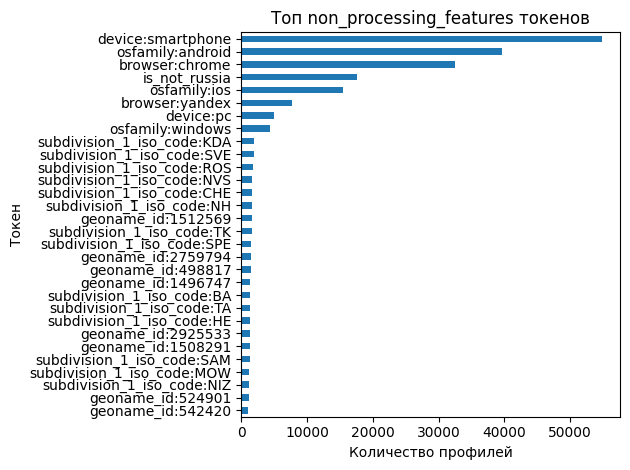

In [37]:
def unique_tokens(x):
    return sorted(set(str(t) for t in listify(x) if not is_empty_value(t)))

profile_df["np_tokens"] = profile_df["non_processing_features"].map(unique_tokens)
profile_df["fs_tokens"] = profile_df["fs_features"].map(unique_tokens)

all_np_tokens = Counter(token for tokens in profile_df["np_tokens"] for token in tokens)
np_token_freq = pd.DataFrame(all_np_tokens.most_common(30), columns=["token", "n_profiles"])
display(np_token_freq)

plt.figure(figsize=(10, 6))
np_token_freq.sort_values("n_profiles").plot(x="token", y="n_profiles", kind="barh", legend=False)
plt.title("Топ non_processing_features токенов")
plt.xlabel("Количество профилей")
plt.ylabel("Токен")
plt.tight_layout()
plt.show()

In [38]:
def extract_token_value(tokens, prefix):
    prefix = prefix + ":"
    for token in tokens:
        if str(token).startswith(prefix):
            return str(token).split(":", 1)[1]
    return np.nan

for prefix, col in [
    ("device", "np_device"),
    ("browser", "np_browser"),
    ("osfamily", "np_osfamily"),
    ("geoname_id", "np_geoname_id"),
    ("subdivision_1_iso_code", "np_region_iso"),
]:
    profile_df[col] = profile_df["np_tokens"].map(lambda tokens, p=prefix: extract_token_value(tokens, p))

tech_cols = ["np_device", "np_browser", "np_osfamily", "np_geoname_id", "np_region_iso"]
display(profile_df[["profile_id"] + tech_cols].head())

,profile_id,np_device,np_browser,np_osfamily,np_geoname_id,np_region_iso
0,000163e0-b9b4-3323-84ea-6495df7fe895,smartphone,chrome,android,625144,HM
1,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,smartphone,NaN,ios,NaN,NaN
2,0002ac9a-fd3f-31a7-9ab5-77b1d3961382,smartphone,chrome,android,NaN,KR
3,00036d8f-9320-39b0-96e9-f0a457fc82a4,smartphone,chrome,android,538560,KRS
4,0003e46e-fc6c-34a8-8358-606d66c1eec2,smartphone,chrome,android,1512569,TK


In [39]:
for col in tech_cols:
    print(f"\n{col}")
    rate = (
        profile_df.groupby(col)
        .agg(
            n_profiles=("profile_id", "size"),
            duplicate_rate=("is_duplicate_entity", "mean"),
        )
        .query("n_profiles >= 100")
        .sort_values("duplicate_rate", ascending=False)
        .head(15)
    )
    display(rate.style.format({"duplicate_rate": "{:.2%}"}))


np_device


,n_profiles,duplicate_rate
np_device,,
pc,5023,27.37%
smartphone,54859,25.65%



np_browser


,n_profiles,duplicate_rate
np_browser,,
safari,128,35.16%
firefox,157,35.03%
opera,327,29.36%
chrome,32478,26.50%
yandex,7685,23.62%



np_osfamily


,n_profiles,duplicate_rate
np_osfamily,,
os-x,226,37.17%
linux,134,33.58%
ios,15457,27.29%
windows,4371,26.20%
android,39709,25.07%



np_geoname_id


,n_profiles,duplicate_rate
np_geoname_id,,
479123,498,49.80%
2640091,111,43.24%
709717,239,38.49%
1216265,378,37.83%
484907,124,37.10%
1512569,1557,34.68%
702658,171,34.50%
480562,272,34.19%
2925533,1283,33.83%



np_region_iso


,n_profiles,duplicate_rate
np_region_iso,,
ULY,572,43.88%
KIR,110,39.09%
AD,152,38.16%
KB,138,37.68%
KO,233,35.62%
35,127,35.43%
NGR,130,35.38%
09,204,35.29%
14,669,35.28%


In [40]:
np_exploded = profile_df[["profile_id", "is_duplicate_entity", "np_tokens"]].explode("np_tokens").dropna(subset=["np_tokens"])
np_token_dup_rate = (
    np_exploded.groupby("np_tokens")
    .agg(
        n_profiles=("profile_id", "nunique"),
        duplicate_rate=("is_duplicate_entity", "mean"),
    )
    .query("n_profiles >= 100")
    .sort_values("duplicate_rate", ascending=False)
)

display(np_token_dup_rate.head(30).style.format({"duplicate_rate": "{:.2%}"}))

,n_profiles,duplicate_rate
np_tokens,,
geoname_id:479123,500,50.00%
subdivision_1_iso_code:ULY,594,45.79%
geoname_id:2640091,114,44.74%
subdivision_1_iso_code:KIR,118,43.22%
geoname_id:709717,245,40.00%
subdivision_1_iso_code:AD,154,38.96%
geoname_id:1216265,378,37.83%
subdivision_1_iso_code:KB,138,37.68%
osfamily:os-x,226,37.17%


### Выводы по этапу

- Технические признаки не должны использоваться как самостоятельное доказательство дубля, но они полезны для объяснения паттернов.
- Для pairwise-модели подойдут признаки `same_device`, `same_osfamily`, `same_browser`, `same_geoname_id`, а также Jaccard similarity по множеству технических токенов.


## 18. Разбор `fs_features`

,token,n_profiles
0,has_account:1345,20069
1,visited_30:1345,17989
2,postman_action_90:smtp_sent,17425
3,postman_campaign_90:exchange,16446
4,postman_response_90:ok,15656
5,postman_action_30:smtp_sent,12810
6,is_gmail,12002
7,postman_campaign_30:exchange,11578
8,postman_response_30:ok,11030
9,mm_event_90:sent,10456


<Figure size 1000x800 with 0 Axes>

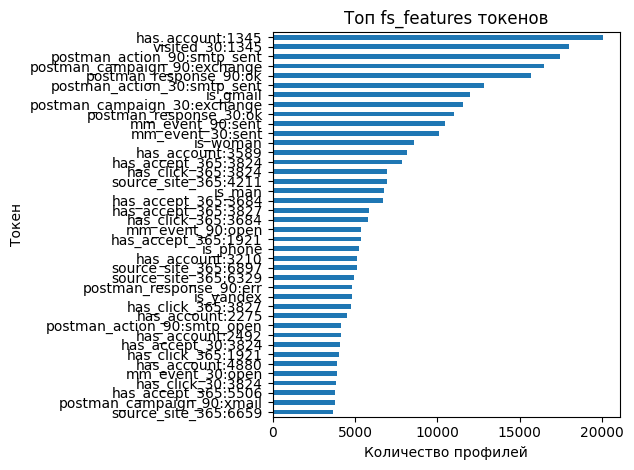

In [41]:
all_fs_tokens = Counter(token for tokens in profile_df["fs_tokens"] for token in tokens)
fs_token_freq = pd.DataFrame(all_fs_tokens.most_common(40), columns=["token", "n_profiles"])
display(fs_token_freq)

plt.figure(figsize=(10, 8))
fs_token_freq.sort_values("n_profiles").plot(x="token", y="n_profiles", kind="barh", legend=False)
plt.title("Топ fs_features токенов")
plt.xlabel("Количество профилей")
plt.ylabel("Токен")
plt.tight_layout()
plt.show()

In [42]:
fs_exploded = profile_df[["profile_id", "is_duplicate_entity", "fs_tokens"]].explode("fs_tokens").dropna(subset=["fs_tokens"])
fs_token_dup_rate = (
    fs_exploded.groupby("fs_tokens")
    .agg(
        n_profiles=("profile_id", "nunique"),
        duplicate_rate=("is_duplicate_entity", "mean"),
    )
    .query("n_profiles >= 100")
    .sort_values("duplicate_rate", ascending=False)
)

display(fs_token_dup_rate.head(30).style.format({"duplicate_rate": "{:.2%}"}))

,n_profiles,duplicate_rate
fs_tokens,,
has_accept_30:6366,119,87.39%
has_click_30:6366,113,84.96%
has_click_365:6878,121,81.82%
source_site_30:4880,606,81.52%
has_accept_365:6366,240,81.25%
has_click_365:6366,242,80.58%
has_click_365:6514,180,78.33%
has_order_30:4880,751,77.36%
has_accept_30:6514,114,77.19%


### Выводы по этапу

- Отдельные behavioral-токены имеют заметно повышенный duplicate rate, поэтому их стоит использовать как признаки риска дублирования и как часть pairwise-сходства.
- Для модели полезны Jaccard similarity по `fs_features`, число общих токенов, совпадения source-site токенов, order/click/account флагов.


## 19. Pairwise EDA: positive pairs против negative pairs

Модель матчинга получает на вход **пару профилей**, поэтому нужно сравнивать пары:

- positive pair: два `profile_id` имеют одинаковый `entity_id`;
- negative pair: два `profile_id` имеют разные `entity_id`.

Ниже формируем все positive pairs и случайную выборку negative pairs того же размера.

In [43]:
def make_positive_pairs(profile_df, max_pairs_per_entity=None):
    pairs = []
    for entity_id, group in profile_df.groupby("entity_id"):
        ids = group["profile_id"].tolist()
        if len(ids) < 2:
            continue
        combs = list(combinations(ids, 2))
        if max_pairs_per_entity is not None and len(combs) > max_pairs_per_entity:
            idx = rng.choice(len(combs), size=max_pairs_per_entity, replace=False)
            combs = [combs[i] for i in idx]
        for a, b in combs:
            if a > b:
                a, b = b, a
            pairs.append((a, b, 1))
    return pd.DataFrame(pairs, columns=["profile_id_1", "profile_id_2", "label"])


def make_negative_pairs(profile_df, n_pairs, random_state=42):
    rng_local = np.random.default_rng(random_state)
    ids = profile_df["profile_id"].to_numpy()
    entity_map = profile_df.set_index("profile_id")["entity_id"].to_dict()
    seen = set()
    pairs = []
    attempts = 0
    max_attempts = n_pairs * 100
    while len(pairs) < n_pairs and attempts < max_attempts:
        a, b = rng_local.choice(ids, size=2, replace=False)
        if a > b:
            a, b = b, a
        key = (a, b)
        if key in seen:
            attempts += 1
            continue
        if entity_map[a] == entity_map[b]:
            attempts += 1
            continue
        seen.add(key)
        pairs.append((a, b, 0))
        attempts += 1
    return pd.DataFrame(pairs, columns=["profile_id_1", "profile_id_2", "label"])

positive_pairs = make_positive_pairs(profile_df)
negative_pairs = make_negative_pairs(profile_df, n_pairs=len(positive_pairs), random_state=RANDOM_STATE)

pairs_df = pd.concat([positive_pairs, negative_pairs], ignore_index=True)
pairs_df = pairs_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Positive pairs: {len(positive_pairs):,}")
print(f"Negative sampled pairs: {len(negative_pairs):,}")
print(f"Total pairwise EDA sample: {len(pairs_df):,}")
display(pairs_df.head())

Positive pairs: 16,363
Negative sampled pairs: 16,363
Total pairwise EDA sample: 32,726


,profile_id_1,profile_id_2,label
0,14d24574-2ff7-39c5-bbdb-bc01620ccb27,77a3f482-d051-3b93-8844-81932423cdf4,1
1,0c368448-4a4b-3470-9ea3-672326006933,aff07e25-688c-3e22-880d-bb3e593777ab,1
2,51a3d60d-586c-30f9-bbec-70c8fb52036c,fc5ecf7f-885e-3455-9d34-0e0fba091594,0
3,7acfa962-55d7-38b7-bc22-1a88f2e15ce0,d2ce5af4-883f-3a62-b906-c7d2102c7cb8,0
4,31811c40-8971-39a6-b703-e3b3f5af4a49,7e54878b-d309-3f67-9063-473a9d30e8a4,1


## 20. Pairwise-признаки сходства

In [44]:
def seq_similarity(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return SequenceMatcher(None, str(a), str(b)).ratio()


def jaccard(a, b):
    sa = set(listify(a))
    sb = set(listify(b))
    if len(sa) == 0 and len(sb) == 0:
        return np.nan
    union = sa | sb
    if len(union) == 0:
        return np.nan
    return len(sa & sb) / len(union)


def both_present_equal(s1, s2):
    return s1.notna() & s2.notna() & (s1 == s2)


def both_present(s1, s2):
    return s1.notna() & s2.notna()

profile_cols_for_pairs = [
    "profile_id", "entity_id", "first_seen_at", "first_name_norm", "last_name_norm",
    "email_local", "email_domain", "phone_norm", "birth_year", "sex_norm",
    "identity_completeness_score", "np_tokens", "fs_tokens",
    "np_device", "np_browser", "np_osfamily", "np_geoname_id", "np_region_iso",
]

for c in ["rt_country", "rt_geoname", "rt_geoid", "rt_tz_offset", "rt_local_hour", "rt_day", "rt_population"]:
    if c in profile_df.columns and c not in profile_cols_for_pairs:
        profile_cols_for_pairs.append(c)

left = profile_df[profile_cols_for_pairs].add_suffix("_1")
right = profile_df[profile_cols_for_pairs].add_suffix("_2")

pair_features = (
    pairs_df
    .merge(left, left_on="profile_id_1", right_on="profile_id_1", how="left")
    .merge(right, left_on="profile_id_2", right_on="profile_id_2", how="left")
)

pair_features["same_phone"] = both_present_equal(pair_features["phone_norm_1"], pair_features["phone_norm_2"])
pair_features["phone_both_present"] = both_present(pair_features["phone_norm_1"], pair_features["phone_norm_2"])
pair_features["same_first_name"] = both_present_equal(pair_features["first_name_norm_1"], pair_features["first_name_norm_2"])
pair_features["first_name_both_present"] = both_present(pair_features["first_name_norm_1"], pair_features["first_name_norm_2"])
pair_features["same_last_name"] = both_present_equal(pair_features["last_name_norm_1"], pair_features["last_name_norm_2"])
pair_features["last_name_both_present"] = both_present(pair_features["last_name_norm_1"], pair_features["last_name_norm_2"])
pair_features["same_email_domain"] = both_present_equal(pair_features["email_domain_1"], pair_features["email_domain_2"])
pair_features["same_birth_year"] = both_present_equal(pair_features["birth_year_1"], pair_features["birth_year_2"])
pair_features["birth_year_both_present"] = both_present(pair_features["birth_year_1"], pair_features["birth_year_2"])

known_sex_1 = pair_features["sex_norm_1"].notna() & ~pair_features["sex_norm_1"].isin(["unknown", "none", "nan"])
known_sex_2 = pair_features["sex_norm_2"].notna() & ~pair_features["sex_norm_2"].isin(["unknown", "none", "nan"])
pair_features["same_known_sex"] = known_sex_1 & known_sex_2 & (pair_features["sex_norm_1"] == pair_features["sex_norm_2"])
pair_features["known_sex_conflict"] = known_sex_1 & known_sex_2 & (pair_features["sex_norm_1"] != pair_features["sex_norm_2"])
pair_features["both_sex_unknown"] = pair_features["sex_norm_1"].isin(["unknown", "none", "nan"]) & pair_features["sex_norm_2"].isin(["unknown", "none", "nan"])

for base_col in ["np_device", "np_browser", "np_osfamily", "np_geoname_id", "np_region_iso", "rt_country", "rt_geoname", "rt_geoid"]:
    c1 = f"{base_col}_1"
    c2 = f"{base_col}_2"
    if c1 in pair_features.columns and c2 in pair_features.columns:
        pair_features[f"same_{base_col}"] = both_present_equal(pair_features[c1], pair_features[c2])

pair_features["first_name_similarity"] = [seq_similarity(a, b) for a, b in zip(pair_features["first_name_norm_1"], pair_features["first_name_norm_2"])]
pair_features["last_name_similarity"] = [seq_similarity(a, b) for a, b in zip(pair_features["last_name_norm_1"], pair_features["last_name_norm_2"])]
pair_features["email_local_similarity"] = [seq_similarity(a, b) for a, b in zip(pair_features["email_local_1"], pair_features["email_local_2"])]

pair_features["np_tokens_jaccard"] = [jaccard(a, b) for a, b in zip(pair_features["np_tokens_1"], pair_features["np_tokens_2"])]
pair_features["fs_tokens_jaccard"] = [jaccard(a, b) for a, b in zip(pair_features["fs_tokens_1"], pair_features["fs_tokens_2"])]

pair_features["created_at_diff_days"] = (
    pair_features["first_seen_at_1"] - pair_features["first_seen_at_2"]
).abs().dt.total_seconds() / 86400

pair_features["created_within_1_hour"] = pair_features["created_at_diff_days"] <= (1 / 24)
pair_features["created_within_1_day"] = pair_features["created_at_diff_days"] <= 1
pair_features["created_within_7_days"] = pair_features["created_at_diff_days"] <= 7

pair_features["min_completeness"] = pair_features[["identity_completeness_score_1", "identity_completeness_score_2"]].min(axis=1)
pair_features["max_completeness"] = pair_features[["identity_completeness_score_1", "identity_completeness_score_2"]].max(axis=1)
pair_features["both_sparse_profiles"] = (pair_features["identity_completeness_score_1"] <= 2) & (pair_features["identity_completeness_score_2"] <= 2)

print(pair_features.shape)
display(pair_features.head())

(32726, 83)


,profile_id_1,profile_id_2,label,entity_id_1,first_seen_at_1,first_name_norm_1,last_name_norm_1,email_local_1,email_domain_1,phone_norm_1,birth_year_1,sex_norm_1,identity_completeness_score_1,np_tokens_1,fs_tokens_1,np_device_1,np_browser_1,np_osfamily_1,np_geoname_id_1,np_region_iso_1,rt_country_1,rt_geoname_1,rt_geoid_1,rt_tz_offset_1,rt_local_hour_1,rt_day_1,rt_population_1,entity_id_2,first_seen_at_2,first_name_norm_2,last_name_norm_2,email_local_2,email_domain_2,phone_norm_2,birth_year_2,sex_norm_2,identity_completeness_score_2,np_tokens_2,fs_tokens_2,np_device_2,np_browser_2,np_osfamily_2,np_geoname_id_2,np_region_iso_2,rt_country_2,rt_geoname_2,rt_geoid_2,rt_tz_offset_2,rt_local_hour_2,rt_day_2,rt_population_2,same_phone,phone_both_present,same_first_name,first_name_both_present,same_last_name,last_name_both_present,same_email_domain,same_birth_year,birth_year_both_present,same_known_sex,known_sex_conflict,both_sex_unknown,same_np_device,same_np_browser,same_np_osfamily,same_np_geoname_id,same_np_region_iso,same_rt_country,same_rt_geoname,same_rt_geoid,first_name_similarity,last_name_similarity,email_local_similarity,np_tokens_jaccard,fs_tokens_jaccard,created_at_diff_days,created_within_1_hour,created_within_1_day,created_within_7_days,min_completeness,max_completeness,both_sparse_profiles
0,14d24574-2ff7-39c5-bbdb-bc01620ccb27,77a3f482-d051-3b93-8844-81932423cdf4,1,b2493335d32f352fc7ec47c571a07324ecfcd40eacd49092322ece696633f804,2026-03-02 15:28:02.013,NaN,NaN,a.uyfomdncag,nw-sp.ru,NaN,NaN,unknown,1,"[browser:firefox, device:pc, osfamily:linux]","[has_accept_30:6366, has_accept_365:3265, has_accept_365:5358, has_accept_365:6366, has_account:1345, has_account:1696, has_account:1813, has_account:2054, ...",pc,firefox,linux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b2493335d32f352fc7ec47c571a07324ecfcd40eacd49092322ece696633f804,2026-03-04 17:30:33.003,NaN,NaN,zepyh,nw-sp.ru,NaN,NaN,unknown,1,"[browser:firefox, device:pc, osfamily:linux]","[has_accept_30:6366, has_accept_365:3265, has_accept_365:5358, has_accept_365:6366, has_account:1345, has_account:1696, has_account:1813, has_account:2054, ...",pc,firefox,linux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,True,False,False,False,False,True,True,True,True,False,False,False,False,False,NaN,NaN,0.117647,1.000000,0.966102,2.085081,False,False,True,1,1,True
1,0c368448-4a4b-3470-9ea3-672326006933,aff07e25-688c-3e22-880d-bb3e593777ab,1,597da83697a05acc9abfed7ae97fdfe939d71581d1c255ce2a320e0e7f8b628b,2025-11-19 11:29:29.948,NaN,NaN,anyyph.tuxjgxfd,mail.ru,NaN,NaN,unknown,1,"[browser:chrome, device:smartphone, geoname_id:625144, is_not_russia, osfamily:android, subdivision_1_iso_code:HM]","[visited_365:2865, visited_365:3265]",smartphone,chrome,android,625144,HM,BY,Minsk,625144.0,3.0,14.0,2.0,1742124.0,597da83697a05acc9abfed7ae97fdfe939d71581d1c255ce2a320e0e7f8b628b,2026-02-26 09:47:26.777,NaN,NaN,jajqahwgtfpsp879,gmail.com,NaN,NaN,unknown,1,"[browser:chrome, device:smartphone, geoname_id:625144, is_not_russia, osfamily:android, subdivision_1_iso_code:HM]","[has_accept_365:3322, has_account:1345, has_account:2891, has_click_365:3322, mm_event_30:sent, mm_event_90:sent, source_site_365:4211, visited_365:2865, vi...",smartphone,chrome,android,625144,HM,BY,Minsk,625144.0,3.0,12.0,3.0,1742124.0,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True,True,NaN,NaN,0.129032,1.000000,0.222222,98.929130,False,False,False,1,1,True
2,51a3d60d-586c-30f9-bbec-70c8fb52036c,fc5ecf7f-885e-3455-9d34-0e0fba091594,0,3ae0d0b6cd664b54fdf06a85c50580c282c30c4bb78f5540c6ff5dafd5355ef0,2026-04-04 11:18:07.090,NaN,NaN,vyfw80684,gmail.com,NaN,NaN,unknown,1,"[browser:chrome, device:smartphone, geoname_id:581049, osfamily:android, subdivision_1_iso_code:ARK]","[has_accept_30:1921, has_accept_30:3684, has_accept_365:1921, has_accept_365:3684, has_accept_365:3824, has_account:1345, has_account:3210, has_click_30:192...",smartphone,chrome,

### Выводы по этапу

- Сильные положительные сигналы: совпадение нормализованного телефона, высокая похожесть email local-part, пересечение редких behavioral-токенов, совпадение гео/устройства при отсутствии конфликтов.
- Сильные отрицательные сигналы: разные заполненные телефоны, конфликт известных значений пола, явно разные даты рождения, нулевая похожесть по всем доступным независимым признакам.


## 20.1. Levenshtein / fuzzy similarity для строковых полей

На этом этапе добавляем отдельные признаки сходства для строковых полей.

Фокусные признаки:

- `email_local_lev_sim` — нормализованная Levenshtein similarity для local-part email;
- `email_local_token_sort_sim` — token-sort similarity для local-part email;
- `first_name_lev_sim` — Levenshtein similarity для имени;
- `last_name_lev_sim` — Levenshtein similarity для фамилии;
- `full_name_token_sort_sim` — token-sort similarity для полного имени, если его можно собрать.

Интерпретация: чем ближе значение к `1`, тем более похожи строки. Значения `NaN` означают, что хотя бы одно из сравниваемых полей отсутствует.

rapidfuzz available: True


,feature,pair_type,coverage,mean,median,p25,p75,n_non_null
0,email_local_lev_sim,negative,100.00%,0.080,0.077,0.000,0.125,16363
1,email_local_lev_sim,positive,100.00%,0.075,0.067,0.000,0.111,16363
2,email_local_token_sort_sim,negative,100.00%,0.168,0.167,0.105,0.222,16363
3,email_local_token_sort_sim,positive,100.00%,0.184,0.182,0.133,0.235,16363
4,first_name_lev_sim,negative,7.46%,0.183,0.143,0.000,0.250,1220
5,first_name_lev_sim,positive,3.78%,0.648,1.000,0.167,1.000,618
6,last_name_lev_sim,negative,0.04%,0.251,0.250,0.229,0.277,6
7,last_name_lev_sim,positive,0.06%,0.482,0.333,0.222,1.000,9
8,full_name_token_sort_sim,negative,7.46%,0.291,0.286,0.182,0.364,1220
9,full_name_token_sort_sim,positive,3.78%,0.661,1.000,0.308,1.000,618


,feature,auc,n_pairs_used,coverage
2,first_name_lev_sim,0.7726,1838,5.62%
4,full_name_token_sort_sim,0.7634,1838,5.62%
3,last_name_lev_sim,0.6204,15,0.05%
1,email_local_token_sort_sim,0.5559,32726,100.00%
0,email_local_lev_sim,0.4753,32726,100.00%


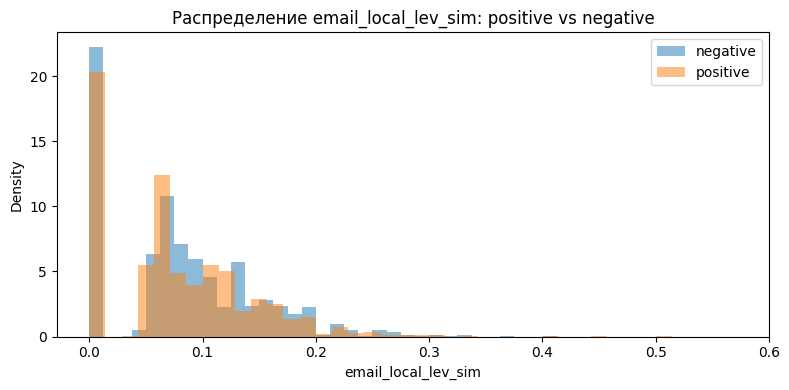

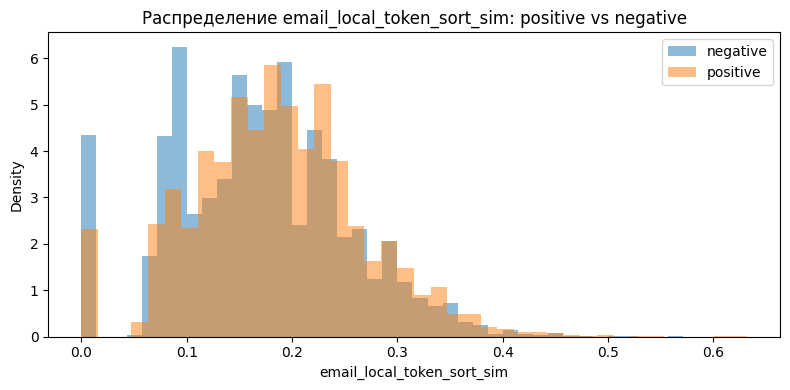

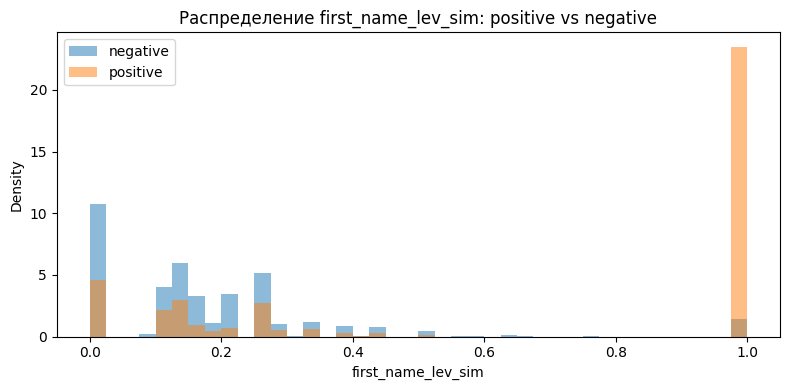

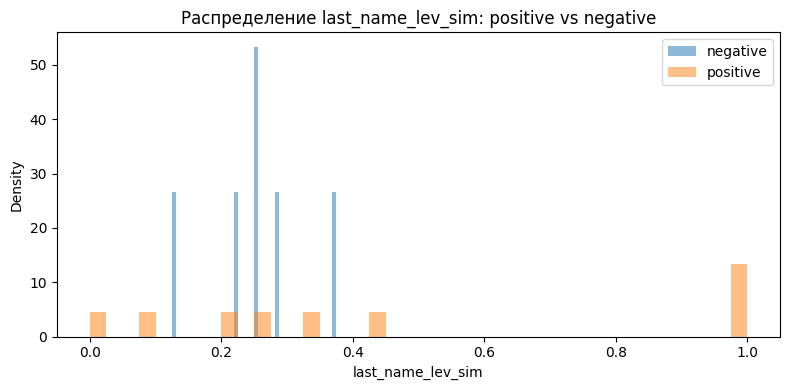

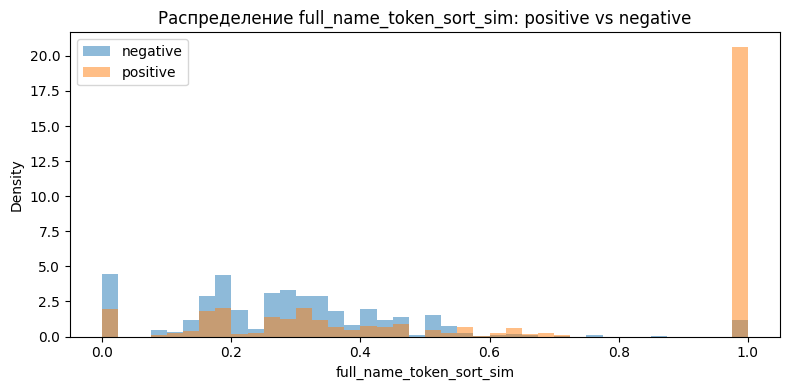

In [45]:
def normalize_for_fuzzy(x):
    """
    Нормализация строки для fuzzy-сравнения.
    Сохраняем буквы и цифры, приводим к нижнему регистру,
    соединяем пробелы и отделяем технические разделители.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    if x in ["", "none", "nan", "null", "unknown"]:
        return np.nan
    x = re.sub(r"[._\-]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x if x else np.nan


def normalize_email_local_for_lev(x):
    """
    Более агрессивная нормализация local-part email для Levenshtein:
    убираем типовые разделители, чтобы ivan.petrov и ivan_petrov
    сравнивались как ivanpetrov.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    if x in ["", "none", "nan", "null", "unknown"]:
        return np.nan
    x = re.sub(r"[._\-]+", "", x)
    x = re.sub(r"\s+", "", x)
    return x if x else np.nan


try:
    from rapidfuzz.distance import Levenshtein as RFLevenshtein
    from rapidfuzz import fuzz as rffuzz
    HAS_RAPIDFUZZ = True
except ImportError:
    RFLevenshtein = None
    rffuzz = None
    HAS_RAPIDFUZZ = False


def levenshtein_distance_py(a, b):
    """
    Fallback-реализация Levenshtein distance на чистом Python.
    Используется только если rapidfuzz не установлен.
    """
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    if len(b) == 0:
        return len(a)

    previous_row = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current_row = [i]
        for j, cb in enumerate(b, start=1):
            insertions = previous_row[j] + 1
            deletions = current_row[j - 1] + 1
            substitutions = previous_row[j - 1] + (ca != cb)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]


def normalized_levenshtein_similarity(a, b):
    """
    Нормализованная Levenshtein similarity в диапазоне [0, 1].
    1.0 — полное совпадение; 0.0 — максимальное различие.
    """
    a = normalize_for_fuzzy(a)
    b = normalize_for_fuzzy(b)
    if pd.isna(a) or pd.isna(b):
        return np.nan

    if HAS_RAPIDFUZZ:
        return RFLevenshtein.normalized_similarity(a, b)

    max_len = max(len(a), len(b))
    if max_len == 0:
        return np.nan
    dist = levenshtein_distance_py(a, b)
    return 1 - dist / max_len


def normalized_email_local_levenshtein_similarity(a, b):
    a = normalize_email_local_for_lev(a)
    b = normalize_email_local_for_lev(b)
    if pd.isna(a) or pd.isna(b):
        return np.nan

    if HAS_RAPIDFUZZ:
        return RFLevenshtein.normalized_similarity(a, b)

    max_len = max(len(a), len(b))
    if max_len == 0:
        return np.nan
    dist = levenshtein_distance_py(a, b)
    return 1 - dist / max_len


def token_sort_similarity(a, b):
    """
    Token-sort similarity. Если установлен rapidfuzz, используется его быстрый fuzz.token_sort_ratio.
    Иначе применяется fallback на SequenceMatcher по отсортированным токенам.
    """
    a = normalize_for_fuzzy(a)
    b = normalize_for_fuzzy(b)
    if pd.isna(a) or pd.isna(b):
        return np.nan

    if HAS_RAPIDFUZZ:
        return rffuzz.token_sort_ratio(a, b) / 100

    tokens_a = sorted(re.findall(r"[a-zа-яё0-9]+", a))
    tokens_b = sorted(re.findall(r"[a-zа-яё0-9]+", b))

    if not tokens_a or not tokens_b:
        return np.nan

    sorted_a = " ".join(tokens_a)
    sorted_b = " ".join(tokens_b)
    return SequenceMatcher(None, sorted_a, sorted_b).ratio()


print(f"rapidfuzz available: {HAS_RAPIDFUZZ}")


def make_full_name(first_name, last_name):
    parts = []
    for x in [first_name, last_name]:
        x = normalize_for_fuzzy(x)
        if not pd.isna(x):
            parts.append(x)
    return " ".join(parts) if parts else np.nan


pair_features["email_local_for_lev_1"] = pair_features["email_local_1"].map(normalize_email_local_for_lev)
pair_features["email_local_for_lev_2"] = pair_features["email_local_2"].map(normalize_email_local_for_lev)

pair_features["full_name_norm_1"] = [
    make_full_name(first, last)
    for first, last in zip(pair_features["first_name_norm_1"], pair_features["last_name_norm_1"])
]

pair_features["full_name_norm_2"] = [
    make_full_name(first, last)
    for first, last in zip(pair_features["first_name_norm_2"], pair_features["last_name_norm_2"])
]

pair_features["email_local_lev_sim"] = [
    normalized_email_local_levenshtein_similarity(a, b)
    for a, b in zip(pair_features["email_local_1"], pair_features["email_local_2"])
]

pair_features["email_local_token_sort_sim"] = [
    token_sort_similarity(a, b)
    for a, b in zip(pair_features["email_local_1"], pair_features["email_local_2"])
]

pair_features["first_name_lev_sim"] = [
    normalized_levenshtein_similarity(a, b)
    for a, b in zip(pair_features["first_name_norm_1"], pair_features["first_name_norm_2"])
]

pair_features["last_name_lev_sim"] = [
    normalized_levenshtein_similarity(a, b)
    for a, b in zip(pair_features["last_name_norm_1"], pair_features["last_name_norm_2"])
]

pair_features["full_name_token_sort_sim"] = [
    token_sort_similarity(a, b)
    for a, b in zip(pair_features["full_name_norm_1"], pair_features["full_name_norm_2"])
]

fuzzy_features = [
    "email_local_lev_sim",
    "email_local_token_sort_sim",
    "first_name_lev_sim",
    "last_name_lev_sim",
    "full_name_token_sort_sim",
]

fuzzy_summary_rows = []
for col in fuzzy_features:
    for label_value, label_name in [(0, "negative"), (1, "positive")]:
        data = pair_features.loc[pair_features["label"] == label_value, col]
        fuzzy_summary_rows.append({
            "feature": col,
            "pair_type": label_name,
            "coverage": data.notna().mean(),
            "mean": data.mean(skipna=True),
            "median": data.median(skipna=True),
            "p25": data.quantile(0.25),
            "p75": data.quantile(0.75),
            "n_non_null": data.notna().sum(),
        })

fuzzy_summary = pd.DataFrame(fuzzy_summary_rows)

display(
    fuzzy_summary.style.format({
        "coverage": "{:.2%}",
        "mean": "{:.3f}",
        "median": "{:.3f}",
        "p25": "{:.3f}",
        "p75": "{:.3f}",
    })
)

from sklearn.metrics import roc_auc_score

auc_rows = []
for col in fuzzy_features:
    temp = pair_features[["label", col]].dropna()
    if temp["label"].nunique() == 2 and len(temp) > 0:
        auc = roc_auc_score(temp["label"].astype(int), temp[col])
    else:
        auc = np.nan
    auc_rows.append({
        "feature": col,
        "auc": auc,
        "n_pairs_used": len(temp),
        "coverage": len(temp) / len(pair_features),
    })

fuzzy_auc = pd.DataFrame(auc_rows).sort_values("auc", ascending=False)

display(
    fuzzy_auc.style.format({
        "auc": "{:.4f}",
        "coverage": "{:.2%}",
    })
)

for col in fuzzy_features:
    plt.figure(figsize=(8, 4))
    for label_value, label_name in [(0, "negative"), (1, "positive")]:
        data = pair_features.loc[pair_features["label"] == label_value, col].dropna()
        if len(data) > 0:
            plt.hist(data, bins=40, alpha=0.5, density=True, label=label_name)
    plt.title(f"Распределение {col}: positive vs negative")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Ключевые выводы по этапу

- Главный практически полезный объект для fuzzy-сравнения — `email_local_norm`, потому что email заполнен у всех, но полный email уникален для каждого профиля.
- Для `first_name` и `last_name` fuzzy-признаки имеют низкое покрытие из-за большого числа пропусков, но могут быть сильным дополнительным сигналом, когда оба значения заполнены.


## 21. Сравнение признаков у positive и negative pairs

In [46]:
bool_features = [
    c for c in pair_features.columns
    if c.startswith("same_") or c.endswith("_both_present") or c in [
        "phone_both_present", "same_known_sex", "known_sex_conflict", "both_sex_unknown",
        "created_within_1_hour", "created_within_1_day", "created_within_7_days", "both_sparse_profiles"
    ]
]

bool_summary = []
for col in bool_features:
    if pair_features[col].dtype == bool or set(pair_features[col].dropna().unique()).issubset({0, 1, True, False}):
        grp = pair_features.groupby("label")[col].mean()
        bool_summary.append({
            "feature": col,
            "negative_rate": grp.get(0, np.nan),
            "positive_rate": grp.get(1, np.nan),
            "lift_positive_vs_negative": (grp.get(1, np.nan) / grp.get(0, np.nan)) if grp.get(0, np.nan) not in [0, np.nan] else np.nan,
        })

bool_summary = pd.DataFrame(bool_summary).sort_values("positive_rate", ascending=False)
display(bool_summary.style.format({
    "negative_rate": "{:.2%}",
    "positive_rate": "{:.2%}",
    "lift_positive_vs_negative": "{:.2f}",
}))

,feature,negative_rate,positive_rate,lift_positive_vs_negative
14,same_np_osfamily,48.01%,95.59%,1.99
12,same_np_device,78.81%,95.56%,1.21
23,both_sparse_profiles,57.17%,85.23%,1.49
16,same_np_region_iso,1.28%,82.73%,64.77
17,same_rt_country,32.16%,82.48%,2.56
11,both_sex_unknown,51.97%,82.27%,1.58
13,same_np_browser,29.30%,80.11%,2.73
15,same_np_geoname_id,0.74%,78.62%,106.31
19,same_rt_geoid,0.73%,77.49%,105.66
18,same_rt_geoname,0.72%,77.46%,107.42


In [47]:
numeric_pair_features = [
    "first_name_similarity", "last_name_similarity", "email_local_similarity",
    "email_local_lev_sim", "email_local_token_sort_sim",
    "first_name_lev_sim", "last_name_lev_sim", "full_name_token_sort_sim",
    "np_tokens_jaccard", "fs_tokens_jaccard", "created_at_diff_days",
    "min_completeness", "max_completeness"
]

numeric_summary = (
    pair_features.groupby("label")[numeric_pair_features]
    .agg(["count", "mean", "median", "std"])
)

display(numeric_summary)

first_name_similarity                               last_name_similarity                               email_local_similarity                                \
                      count      mean    median       std                count      mean    median       std                  count      mean    median       std   
label                                                                                                                                                               
0                      1220  0.283609  0.266667  0.202621                    6  0.303663  0.296703  0.159194                  16363  0.155779  0.153846  0.080766   
1                       618  0.686341  1.000000  0.385021                    9  0.512698  0.333333  0.375391                  16363  0.163833  0.153846  0.080340   

      email_local_lev_sim                               email_local_token_sort_sim                               first_name_lev_sim                                \
                    count      mean    median       std                      count      mean    median       std              count      mean    median       std   
label                                                                                                                                                               
0                   16363  0.079764  0.076923  0.065710                      16363  0.168135  0.166667  0.083135               1220  0.182507  0.142857  0.200517   
1                   16363  0.074840  0.066667  0.063675                      16363  0.184286  0.181818  0.080740                618  0.647966  1.000000  0.427323   

      last_name_lev_sim                               full_name_token_sort_sim                               np_tokens_jaccard                               fs_tokens_jaccard  \
                  count      mean    median       std                    count      mean    median       std             count      mean    median       std             count   
label                                                                                                                                                                            
0                     6  0.251323  0.250000  0.081592                     1220  0.290875  0.285714  0.192543             16362  0.238410  0.222222  0.176053             13267   
1                     9  0.481570  0.333333  0.407658                      618  0.661492  1.000000  0.370257             16345  0.908296  1.000000  0.206269              6827   

                                    created_at_diff_days                                  min_completeness                            max_completeness                             
           mean    median       std                count       mean     median        std            count      mean median       std            count      mean median       std  
label                                                                                                                                                                              
0      0.022638  0.000000  0.056580                16363  59.020652  51.663143  41.879309            16363  1.190185    1.0  0.525836            16363  2.126322    2.0  1.075783  
1      0.471646  0.473684  0.377427                16363  16.378019   0.054902  31.728692            16363  1.089409    1.0  0.380604            16363  1.408299    1.0  0.822877

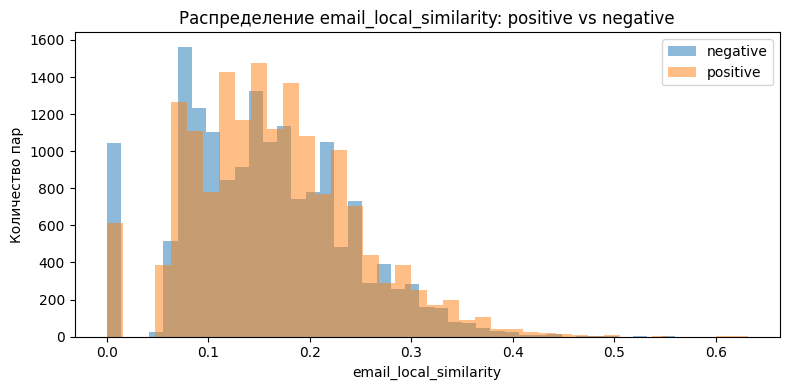

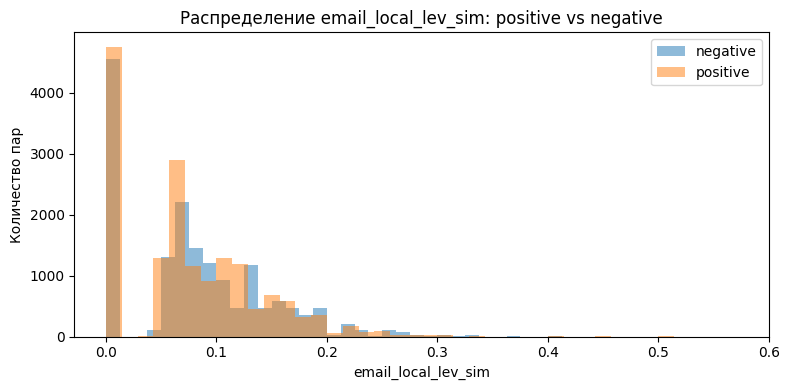

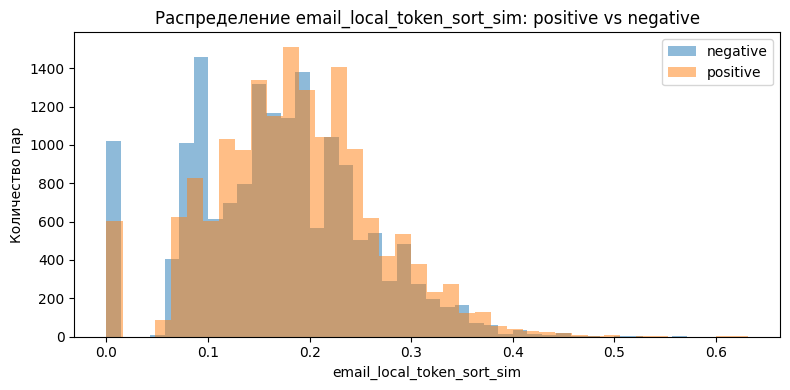

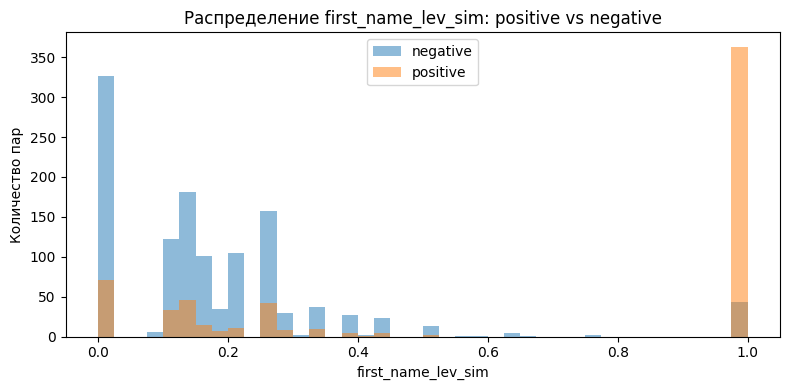

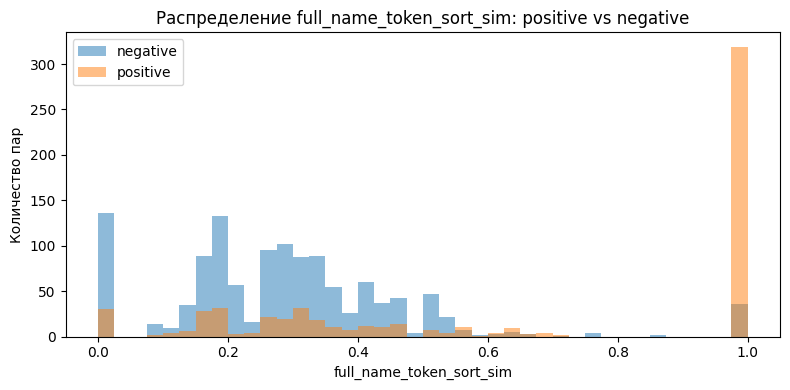

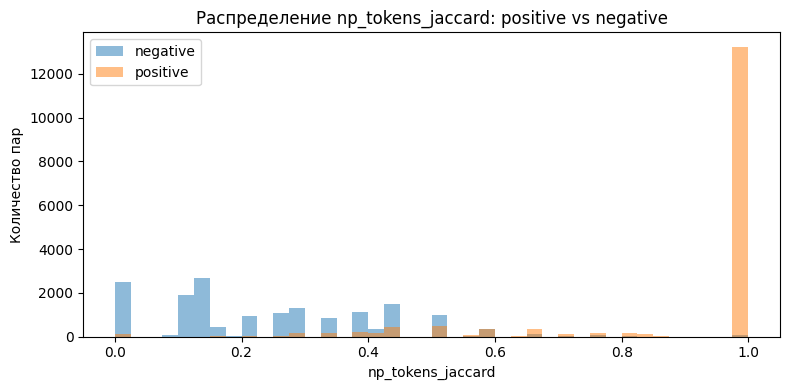

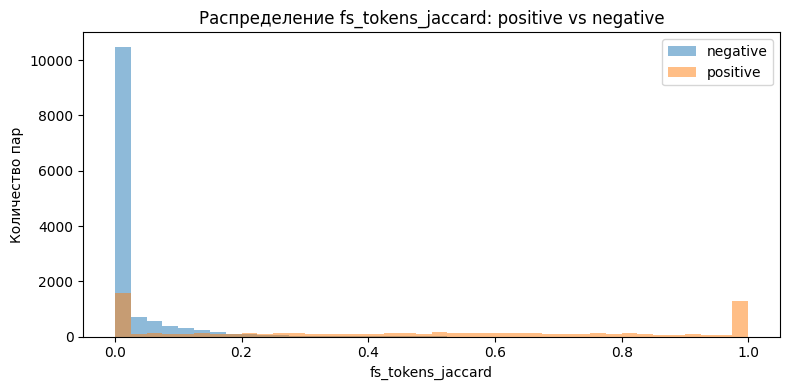

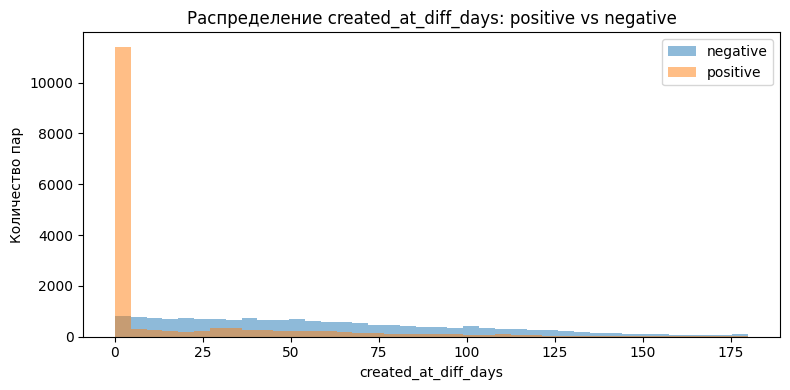

In [48]:
for col in [
    "email_local_similarity", "email_local_lev_sim", "email_local_token_sort_sim",
    "first_name_lev_sim", "full_name_token_sort_sim",
    "np_tokens_jaccard", "fs_tokens_jaccard", "created_at_diff_days"
]:
    plt.figure(figsize=(8, 4))
    for label_value, label_name in [(0, "negative"), (1, "positive")]:
        data = pair_features.loc[pair_features["label"] == label_value, col].dropna()
        if col == "created_at_diff_days":
            data = data.clip(upper=180)
        plt.hist(data, bins=40, alpha=0.5, label=label_name)
    plt.title(f"Распределение {col}: positive vs negative")
    plt.xlabel(col)
    plt.ylabel("Количество пар")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Выводы по этапу

- На этом этапе нужно отобрать признаки, у которых распределения для positive и negative pairs заметно различаются.
- Если признак имеет высокий mean/median у positive pairs и низкий у negative pairs, он является хорошим кандидатом для итогового набора признаков сравнения.
- Если распределения почти совпадают, признак либо слабый, либо полезен только в комбинации с другими признаками.
- Для признаков с большим количеством `NaN` важно анализировать не только значение similarity, но и покрытие: сильный признак с низким покрытием полезен как дополнительный сигнал.


## 22. Разработка признаков для сравнения профилей

Фиксация набора pairwise-признаков, которые можно использовать для сравнения двух клиентских профилей. На этом уровне одна строка в `pair_features` соответствует паре `profile_id_1` и `profile_id_2`, а признаки описывают степень их сходства, различия и полноту доступной информации.

Признаки разделены на следующие группы:

1. **Контактные признаки** — телефон и email признаки.
2. **ФИО-признаки** — exact-match и fuzzy similarity для имени, фамилии и полного имени.
3. **Демографические признаки** — год рождения и пол с учетом `unknown`.
4. **Географические признаки** — страна, город/geoid, часовой пояс, региональные токены.
5. **Технические признаки** — устройство, браузер, ОС, технические токены.
6. **Поведенческие признаки** — пересечение `fs_features`.
7. **Временные признаки** — расстояние между датами появления профилей.
8. **Признаки полноты** — насколько оба профиля заполнены и являются ли они sparse.

In [49]:
feature_catalog = pd.DataFrame([
    {
        "feature_group": "contact_phone",
        "feature_name": "same_phone",
        "source_fields": "phone_norm",
        "calculation_logic": "1, если нормализованные телефоны совпадают и оба заполнены",
        "interpretation": "Очень сильный положительный сигнал, но с низким покрытием",
        "priority": "high",
    },
    {
        "feature_group": "contact_phone",
        "feature_name": "phone_both_present",
        "source_fields": "phone_norm",
        "calculation_logic": "1, если телефон заполнен у обоих профилей",
        "interpretation": "Флаг применимости телефонного сравнения",
        "priority": "medium",
    },
    {
        "feature_group": "email",
        "feature_name": "same_email_domain",
        "source_fields": "email_domain",
        "calculation_logic": "1, если домен email совпадает",
        "interpretation": "Слабый/средний сигнал; массовые домены сами по себе не доказывают дубль",
        "priority": "medium",
    },
    {
        "feature_group": "email",
        "feature_name": "email_local_similarity",
        "source_fields": "email_local",
        "calculation_logic": "SequenceMatcher similarity между local-part email",
        "interpretation": "Один из ключевых признаков, потому что email заполнен почти у всех, но exact email уникален",
        "priority": "high",
    },
    {
        "feature_group": "email",
        "feature_name": "email_local_lev_sim",
        "source_fields": "email_local_norm",
        "calculation_logic": "Нормализованная Levenshtein similarity между local-part email",
        "interpretation": "Улавливает опечатки и вариации написания email local-part",
        "priority": "high",
    },
    {
        "feature_group": "email",
        "feature_name": "email_local_token_sort_sim",
        "source_fields": "email_local_norm",
        "calculation_logic": "Token-sort similarity для local-part email",
        "interpretation": "Полезно, если части email переставлены или разделены разными символами",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "same_first_name",
        "source_fields": "first_name_norm",
        "calculation_logic": "1, если нормализованные имена совпадают и оба заполнены",
        "interpretation": "Полезный, но неполный сигнал из-за высокой доли пропусков",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "first_name_lev_sim",
        "source_fields": "first_name_norm",
        "calculation_logic": "Нормализованная Levenshtein similarity для имени",
        "interpretation": "Улавливает опечатки и варианты транслитерации имени",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "same_last_name",
        "source_fields": "last_name_norm",
        "calculation_logic": "1, если нормализованные фамилии совпадают и обе заполнены",
        "interpretation": "Может быть сильным сигналом, но покрытие низкое",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "last_name_lev_sim",
        "source_fields": "last_name_norm",
        "calculation_logic": "Нормализованная Levenshtein similarity для фамилии",
        "interpretation": "Дополнительный fuzzy-сигнал при заполненной фамилии",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "full_name_token_sort_sim",
        "source_fields": "first_name_norm + last_name_norm",
        "calculation_logic": "Token-sort similarity для полного имени",
        "interpretation": "Полезно, если имя и фамилия меняются местами или частично заполнены",
        "priority": "medium",
    },
    {
        "feature_group": "demographic",
        "feature_name": "same_birth_year",
        "source_fields": "birth_year",
        "calculation_logic": "1, если год рождения совпадает и оба значения заполнены",
        "interpretation": "Сильный дополнительный сигнал при наличии, но покрытие очень низкое",
        "priority": "low",
    },
    {
        "feature_group": "demographic",
        "feature_name": "same_known_sex",
        "source_fields": "sex_norm",
        "calculation_logic": "1, если известный пол совпадает у обоих профилей",
        "interpretation": "Слабый/средний положительный сигнал; unknown нельзя считать полноценным совпадением",
        "priority": "medium",
    },
    {
        "feature_group": "demographic",
        "feature_name": "known_sex_conflict",
        "source_fields": "sex_norm",
        "calculation_logic": "1, если оба значения пола известны и различаются",
        "interpretation": "Отрицательный сигнал, потенциальный конфликт идентичности",
        "priority": "high",
    },
    {
        "feature_group": "geo",
        "feature_name": "same_rt_geoid / same_rt_geoname / same_rt_country",
        "source_fields": "realtime_features",
        "calculation_logic": "Сравнение распарсенных географических полей",
        "interpretation": "Полезно как вспомогательный контекст; города и страны могут совпадать у разных людей",
        "priority": "medium",
    },
    {
        "feature_group": "technical",
        "feature_name": "same_np_device / same_np_browser / same_np_osfamily",
        "source_fields": "non_processing_features",
        "calculation_logic": "Сравнение извлеченных device/browser/osfamily",
        "interpretation": "Слабые отдельные сигналы, полезны в комбинации с email/гео/поведением",
        "priority": "medium",
    },
    {
        "feature_group": "technical",
        "feature_name": "np_tokens_jaccard",
        "source_fields": "non_processing_features",
        "calculation_logic": "Jaccard similarity между множествами технических токенов",
        "interpretation": "Показывает техническую похожесть профилей: устройство, браузер, ОС, региональные токены",
        "priority": "high",
    },
    {
        "feature_group": "behavioral",
        "feature_name": "fs_tokens_jaccard",
        "source_fields": "fs_features",
        "calculation_logic": "Jaccard similarity между множествами behavioral/marketplace токенов",
        "interpretation": "Один из ключевых признаков для sparse-профилей, где мало персональных данных",
        "priority": "high",
    },
    {
        "feature_group": "temporal",
        "feature_name": "created_at_diff_days",
        "source_fields": "first_seen_at",
        "calculation_logic": "Абсолютная разница между датами первого появления профилей, в днях",
        "interpretation": "Помогает отличать почти одновременные регистрации от долгосрочного разнесения профилей",
        "priority": "medium",
    },
    {
        "feature_group": "temporal",
        "feature_name": "created_within_1_hour / 1_day / 7_days",
        "source_fields": "first_seen_at",
        "calculation_logic": "Флаги близости дат создания профилей",
        "interpretation": "Полезны для поиска серийных или технических паттернов появления дублей",
        "priority": "medium",
    },
    {
        "feature_group": "completeness",
        "feature_name": "min_completeness / max_completeness / both_sparse_profiles",
        "source_fields": "identity_completeness_score",
        "calculation_logic": "Сравнение полноты identity-полей двух профилей",
        "interpretation": "Показывает надежность сравнения: sparse-пары требуют осторожной интерпретации",
        "priority": "high",
    },
])

pd.set_option("display.max_colwidth", 140)
display(feature_catalog)


,feature_group,feature_name,source_fields,calculation_logic,interpretation,priority
0,contact_phone,same_phone,phone_norm,"1, если нормализованные телефоны совпадают и оба заполнены","Очень сильный положительный сигнал, но с низким покрытием",high
1,contact_phone,phone_both_present,phone_norm,"1, если телефон заполнен у обоих профилей",Флаг применимости телефонного сравнения,medium
2,email,same_email_domain,email_domain,"1, если домен email совпадает",Слабый/средний сигнал; массовые домены сами по себе не доказывают дубль,medium
3,email,email_local_similarity,email_local,SequenceMatcher similarity между local-part email,"Один из ключевых признаков, потому что email заполнен почти у всех, но exact email уникален",high
4,email,email_local_lev_sim,email_local_norm,Нормализованная Levenshtein similarity между local-part email,Улавливает опечатки и вариации написания email local-part,high
5,email,email_local_token_sort_sim,email_local_norm,Token-sort similarity для local-part email,"Полезно, если части email переставлены или разделены разными символами",medium
6,name,same_first_name,first_name_norm,"1, если нормализованные имена совпадают и оба заполнены","Полезный, но неполный сигнал из-за высокой доли пропусков",medium
7,name,first_name_lev_sim,first_name_norm,Нормализованная Levenshtein similarity для имени,Улавливает опечатки и варианты транслитерации имени,medium
8,name,same_last_name,last_name_norm,"1, если нормализованные фамилии совпадают и обе заполнены","Может быть сильным сигналом, но покрытие низкое",medium
9,name,last_name_lev_sim,last_name_norm,Нормализованная Levenshtein similarity для фамилии,Дополнительный fuzzy-сигнал при заполненной фамилии,medium


In [50]:
catalog_feature_names = []
for value in feature_catalog["feature_name"]:
    for part in str(value).replace(" / ", "|").split("|"):
        catalog_feature_names.append(part.strip())

available_catalog_features = sorted([f for f in catalog_feature_names if f in pair_features.columns])
missing_catalog_features = sorted([f for f in catalog_feature_names if f not in pair_features.columns])

print("Признаки из каталога, уже доступные в pair_features:")
print(available_catalog_features)

print("\nПризнаки из каталога, которые описаны концептуально или требуют дополнительной детализации:")
print(missing_catalog_features)

feature_diagnostics = []
for col in pair_features.columns:
    if col in ["profile_id_1", "profile_id_2", "entity_id_1", "entity_id_2", "label"]:
        continue
    if pair_features[col].dtype == "object":
        continue

    temp = pair_features[["label", col]].copy()
    coverage = temp[col].notna().mean()

    neg_mean = temp.loc[temp["label"] == 0, col].mean()
    pos_mean = temp.loc[temp["label"] == 1, col].mean()

    abs_diff = np.nan
    if pd.notna(pos_mean) and pd.notna(neg_mean):
        diff = pos_mean - neg_mean
        if isinstance(diff, pd.Timedelta):
            abs_diff = abs(diff).total_seconds()
        elif pd.api.types.is_numeric_dtype(diff):
            abs_diff = abs(diff)
        else:
            abs_diff = np.nan

    feature_diagnostics.append({
        "feature": col,
        "coverage": coverage,
        "negative_mean": neg_mean,
        "positive_mean": pos_mean,
        "abs_mean_diff": abs_diff,
    })

feature_diagnostics = (
    pd.DataFrame(feature_diagnostics)
    .sort_values(["abs_mean_diff", "coverage"], ascending=False)
)

display(feature_diagnostics.head(30).style.format({
    "coverage": "{:.2%}",
    "negative_mean": "{:.4f}",
    "positive_mean": "{:.4f}",
    "abs_mean_diff": "{:.4f}",
}))

Признаки из каталога, уже доступные в pair_features:
['both_sparse_profiles', 'created_at_diff_days', 'created_within_1_hour', 'email_local_lev_sim', 'email_local_similarity', 'email_local_token_sort_sim', 'first_name_lev_sim', 'fs_tokens_jaccard', 'full_name_token_sort_sim', 'known_sex_conflict', 'last_name_lev_sim', 'max_completeness', 'min_completeness', 'np_tokens_jaccard', 'phone_both_present', 'same_birth_year', 'same_email_domain', 'same_first_name', 'same_known_sex', 'same_last_name', 'same_np_browser', 'same_np_device', 'same_np_osfamily', 'same_phone', 'same_rt_country', 'same_rt_geoid', 'same_rt_geoname']

Признаки из каталога, которые описаны концептуально или требуют дополнительной детализации:
['1_day', '7_days']


,feature,coverage,negative_mean,positive_mean,abs_mean_diff
8,first_seen_at_2,100.00%,.4f,.4f,2650140.7067
0,first_seen_at_1,100.00%,.4f,.4f,2620453.5588
3,rt_geoid_1,84.66%,1135482.0635,795502.9746,339979.0890
11,rt_geoid_2,84.66%,1132961.9056,793346.4892,339615.4163
7,rt_population_1,84.61%,1224155.9124,888330.9449,335824.9675
15,rt_population_2,84.63%,1185277.5470,891875.9687,293401.5782
41,created_at_diff_days,100.00%,59.0207,16.3780,42.6426
1,birth_year_1,0.39%,1976.1957,1978.1714,1.9758
32,same_np_region_iso,100.00%,0.0128,0.8273,0.8145
31,same_np_geoname_id,100.00%,0.0074,0.7862,0.7788


### Выводы по этапу

- Для сравнения профилей нужен не один универсальный признак, а набор сигналов: контактные, строковые fuzzy-признаки, демографические, географические, технические, поведенческие, временные и признаки полноты.
- Наиболее перспективные признаки для данного датасета: `email_local_lev_sim`, `email_local_similarity`, `fs_tokens_jaccard`, `np_tokens_jaccard`, `same_phone`, `same_first_name`, `known_sex_conflict`, `created_at_diff_days`, а также флаги полноты профилей.
- `phone` является сильным сигналом при совпадении, но не покрывает большую часть профилей. Поэтому он должен использоваться как дополнительный идентификатор, а не как единственная основа сравнения.
- `email` важно использовать через производные признаки: local-part similarity, Levenshtein similarity, token-sort similarity, домен и нормализованные варианты local-part. Exact-match полного email в этом датасете не решает задачу поиска дублей.
- Для `sex`, `birthday`, `first_name`, `last_name` нужно отдельно учитывать покрытие. Отсутствие значения не является отрицательным сигналом; это признак неопределенности.
- `fs_features` и `non_processing_features` особенно важны для sparse-профилей, где классические персональные поля отсутствуют или заполнены частично.

## 23. Основные выводы EDA

1. **Основная единица анализа — `profile_id`, а не исходная строка.** В исходном файле один профиль может встречаться несколько раз, поэтому перед анализом дублей данные нужно агрегировать до profile-level таблицы.

2. **`entity_id` выступает как ground truth cluster.** Если один `entity_id` содержит несколько `profile_id`, такие профили считаются размеченной duplicate-группой.

3. **В данных есть существенная доля duplicate-профилей.** После агрегации видно, что часть `entity_id` содержит более одного `profile_id`; именно эти группы формируют positive-примеры для pairwise EDA.

4. **Классические identity-поля сильно разрежены.** `birthday`, `last_name`, `phone` и `first_name` имеют высокую долю пропусков. Эти поля полезны, но не могут быть единственной основой сравнения профилей.

5. **Email заполнен почти у всех профилей, но exact-match полного email практически не решает задачу.** Его основная ценность — в производных признаках: local-part similarity, Levenshtein similarity, token-sort similarity, домен, наличие цифр и структурные паттерны local-part.

6. **Телефон — высокоточный, но низкопокрывающий сигнал.** Совпадение нормализованного телефона может быть сильным аргументом в пользу дубля, однако отсутствие телефона у большинства профилей требует дополнительных источников сходства.

7. **ФИО и дата рождения необходимо использовать осторожно.** Совпадение имени/фамилии или года рождения может усиливать уверенность, но из-за пропусков и возможных вариаций написания эти признаки должны сопровождаться fuzzy-сравнением и флагами заполненности.

8. **Технические и поведенческие признаки критически важны для sparse-профилей.** `non_processing_features`, `realtime_features` и `fs_features` дают дополнительные сигналы там, где ФИО, телефон и дата рождения отсутствуют.

9. **Pairwise EDA является центральной частью анализа.** Для задачи Entity Resolution важно сравнивать не отдельные профили, а пары профилей: positive pairs с одинаковым `entity_id` и negative pairs с разными `entity_id`.

10. **Levenshtein/fuzzy similarity имеет большой вклад в признаки при обнаружении дубликатов.** Особенно для `email_local`, а также для `first_name`, `last_name` и `full_name`, когда соответствующие поля заполнены. Полезность этих признаков нужно оценивать через разделение positive/negative pairs и AUC/распределения.

# Построение модели

In [2]:
import pandas as pd
import numpy as np
import networkx as nx

import random
from itertools import combinations
from difflib import SequenceMatcher

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, adjusted_rand_score, normalized_mutual_info_score

from catboost import CatBoostClassifier

### Загрузка датасета

In [82]:
df = pd.read_parquet("profile_level_dataset_parquet.parquet")

### Подготовка данных для модели

In [50]:
data = df.copy()

data["name_clean"] = (
    data["first_name_norm"].fillna("").astype(str) + " " +
    data["last_name_norm"].fillna("").astype(str)
).str.lower().str.strip()

data["email_local_clean"] = data["email_local"].fillna("").astype(str).str.lower().str.strip()
data["email_domain_clean"] = data["email_domain"].fillna("").astype(str).str.lower().str.strip()

data["phone_clean"] = (
    data["phone_norm"]
    .fillna("")
    .astype(str)
    .str.replace(r"\D", "", regex=True)
)

data["birth_clean"] = data["birth_year"]

data["sex_clean"] = data["sex_norm"].fillna("unknown").astype(str).str.lower().str.strip()

data["city_clean"] = data["rt_geoname"].fillna("").astype(str).str.lower().str.strip()

data["device_clean"] = data["np_device"].fillna("").astype(str).str.lower().str.strip()
data["browser_clean"] = data["np_browser"].fillna("").astype(str).str.lower().str.strip()
data["os_clean"] = data["np_osfamily"].fillna("").astype(str).str.lower().str.strip()
data["region_clean"] = data["np_region_iso"].fillna("").astype(str).str.lower().str.strip()

data["np_tokens_clean"] = data["np_tokens"].fillna("").astype(str).str.lower()
data["fs_tokens_clean"] = data["fs_tokens"].fillna("").astype(str).str.lower()
data["realtime_features_clean"] = data["realtime_features"].fillna("").astype(str).str.lower()

data["rt_visit_count_clean"] = pd.to_numeric(
    data["rt_visit_count"],
    errors="coerce"
).fillna(0)
data["profile_lifetime_days_clean"] = pd.to_numeric(
    data["profile_lifetime_days"],
    errors="coerce"
).fillna(0)

print(data[[
    "profile_id", "entity_id",
    "name_clean", "email_local_clean", "email_domain_clean",
    "phone_clean", "birth_clean", "sex_clean",
    "city_clean", "device_clean", "browser_clean", "os_clean", "region_clean",
    "np_tokens_clean", "fs_tokens_clean", "realtime_features_clean", "rt_visit_count_clean", "profile_lifetime_days_clean"
]].head())

                             profile_id  \
0  000163e0-b9b4-3323-84ea-6495df7fe895   
1  0001ced1-cecc-3dc9-b4c1-acf162c8b2b5   
2  0002ac9a-fd3f-31a7-9ab5-77b1d3961382   
3  00036d8f-9320-39b0-96e9-f0a457fc82a4   
4  0003e46e-fc6c-34a8-8358-606d66c1eec2   

                                           entity_id name_clean  \
0  266eb686284a35db45a797ef75c01fc276e71fee1eb2aa...              
1  ef07a5be121a62611f6b1f7e25fed25a0d02b9571d7bbc...              
2  244363f995686f034394129500ab9c06fa262eefa04cfc...   василиса   
3  5b3e5b68690777e70e9f394d45ebb85aeb5f12c68b2f06...              
4  eb99135fb3e4af6723c6daf1ac22f4f9c15218c3f17a53...              

  email_local_clean email_domain_clean  phone_clean  birth_clean sex_clean  \
0     srnxztxqa8004          gmail.com                       NaN   unknown   
1           wjpfhmp             vk.com  79959678942          NaN   unknown   
2     qleopvd052996          gmail.com                       NaN   unknown   
3       hxubxrhcy67       

Данные были приведены к единому формату: текстовые признаки очищены и приведены к нижнему регистру, email разделен на локальную часть и домен, телефон нормализован до последовательности цифр. 

Для поведенческих признаков (np_tokens, fs_tokens, realtime_features) использовалась Jaccard similarity, а также были добавлены числовые признаки различий (например, число визитов и длительность жизни профиля).

В результате каждый профиль представлен набором признаков, пригодных для попарного сравнения.

In [51]:
required_cols = ["profile_id", "entity_id", "email"]

missing = [c for c in required_cols if c not in data.columns]
assert not missing, f"Не хватает колонок: {missing}"

print("Уникальных profile_id:", df["profile_id"].nunique())
print("Уникальных entity_id:", df["entity_id"].nunique())

Уникальных profile_id: 61927
Уникальных entity_id: 53369


Это означает, что в нашем датасете ~13.8% дублей. Будем считать, что в реальной жизни соотношение такое же (для создания соответствующего дисбаланса в train и test датасетах)

Разделим данные на train/test/validation датасеты  
Разделение данных выполнялось по entity_id, чтобы избежать утечки данных: профили одного пользователя не попадают одновременно в train и validation/test.

In [52]:
entities = data['entity_id'].unique()

train_entities, temp_entities = train_test_split(entities, test_size=0.3, random_state=42)
val_entities, test_entities = train_test_split(temp_entities, test_size=0.5, random_state=42)

train_df = data[data['entity_id'].isin(train_entities)]
val_df = data[data['entity_id'].isin(val_entities)]
test_df = data[data['entity_id'].isin(test_entities)]

print(len(train_df), len(val_df), len(test_df))

43449 9266 9212


### Генерация пар

Задача сведена к бинарной классификации пар профилей. Позитивные пары формировались из профилей с одинаковым entity_id, негативные - из профилей с разными entity_id.

Позитивные пары

In [53]:
def generate_positive_pairs(df):
    pairs = []
    
    grouped = df.groupby('entity_id')
    
    for _, group in grouped:
        ids = group['profile_id'].values
        
        if len(ids) > 1:
            for a, b in combinations(ids, 2):
                pairs.append((a, b, 1))
    
    return pd.DataFrame(pairs, columns=['id1', 'id2', 'target'])

Негативные пары

In [54]:
def generate_negative_pairs(df, n_samples=10000):
    pairs = []
    
    ids = df[['profile_id', 'entity_id']].values
    
    while len(pairs) < n_samples:
        a, b = random.sample(list(ids), 2)
        
        if a[1] != b[1]:  # разные entity
            pairs.append((a[0], b[0], 0))
    
    return pd.DataFrame(pairs, columns=['id1', 'id2', 'target'])

#### Собираем пары для обучения

В исходных данных доля дублей невысокая, однако при формировании пар возникает сильный дисбаланс (большинство пар - не дубли). Были рассмотрены несбалансированные выборки, чтобы приблизить обучение к реальным условиям.

In [55]:
pos_pairs = generate_positive_pairs(train_df)
neg_pairs = generate_negative_pairs(train_df, n_samples=len(pos_pairs) * 7)

pairs_df = pd.concat([pos_pairs, neg_pairs]).sample(frac=1).reset_index(drop=True)

print(pairs_df.shape)

(110384, 3)


### Feature engineering

In [56]:
df_indexed = data.set_index('profile_id')

#### Генерация признаков

In [57]:
def sim(a, b):
    if pd.isna(a) or pd.isna(b):
        return 0
    
    a = str(a)
    b = str(b)
    
    if a == "" or b == "":
        return 0
    
    return SequenceMatcher(None, a, b).ratio()


def exact_match(a, b):
    if pd.isna(a) or pd.isna(b):
        return 0
    
    a = str(a)
    b = str(b)
    
    if a == "" or b == "":
        return 0
    
    return int(a == b)


def to_token_set(x):
    if pd.isna(x):
        return set()
    
    x = str(x).lower()
    
    for ch in "[]{}()',\"":
        x = x.replace(ch, " ")
    
    tokens = x.split()
    return set(tokens)


def jaccard_sim(a, b):
    set_a = to_token_set(a)
    set_b = to_token_set(b)
    
    if len(set_a) == 0 or len(set_b) == 0:
        return 0
    
    return len(set_a & set_b) / len(set_a | set_b)


def build_features(pairs, df_lookup):
    features = []
    
    for _, row in pairs.iterrows():
        p1 = df_lookup.loc[row["id1"]]
        p2 = df_lookup.loc[row["id2"]]
        
        f = {}
        
        # identity features
        f["name_sim"] = sim(p1["name_clean"], p2["name_clean"])
        f["email_local_sim"] = sim(p1["email_local_clean"], p2["email_local_clean"])
        f["email_domain_match"] = exact_match(p1["email_domain_clean"], p2["email_domain_clean"])
        
        f["phone_match"] = exact_match(p1["phone_clean"], p2["phone_clean"])
        f["birth_match"] = exact_match(p1["birth_clean"], p2["birth_clean"])
        f["sex_match"] = exact_match(p1["sex_clean"], p2["sex_clean"])
        f["city_match"] = exact_match(p1["city_clean"], p2["city_clean"])
        
        # technical / behavioral exact matches
        f["device_match"] = exact_match(p1["device_clean"], p2["device_clean"])
        f["browser_match"] = exact_match(p1["browser_clean"], p2["browser_clean"])
        f["os_match"] = exact_match(p1["os_clean"], p2["os_clean"])
        f["region_match"] = exact_match(p1["region_clean"], p2["region_clean"])
        
        # behavioral token similarity
        f["np_tokens_jaccard"] = jaccard_sim(
            p1["np_tokens_clean"],
            p2["np_tokens_clean"]
        )
        
        f["fs_tokens_jaccard"] = jaccard_sim(
            p1["fs_tokens_clean"],
            p2["fs_tokens_clean"]
        )
        
        f["realtime_features_jaccard"] = jaccard_sim(
            p1["realtime_features_clean"],
            p2["realtime_features_clean"]
        )
        
        # numeric behavioral differences
        f["rt_visit_count_diff"] = abs(
            p1["rt_visit_count_clean"] - p2["rt_visit_count_clean"]
        )
        
        f["profile_lifetime_days_diff"] = abs(
            p1["profile_lifetime_days_clean"] - p2["profile_lifetime_days_clean"]
        )
        
        # aggregated features
        f["n_exact_matches"] = (
            f["email_domain_match"]
            + f["phone_match"]
            + f["birth_match"]
            + f["sex_match"]
            + f["city_match"]
            + f["device_match"]
            + f["browser_match"]
            + f["os_match"]
            + f["region_match"]
        )
        
        f["behavior_mean_sim"] = (
            f["np_tokens_jaccard"]
            + f["fs_tokens_jaccard"]
            + f["realtime_features_jaccard"]
        ) / 3
        
        f["target"] = row["target"]
        features.append(f)
    
    return pd.DataFrame(features)

#### Собираем train features

In [58]:
train_features = build_features(pairs_df, df_indexed)

X_train = train_features.drop(columns=['target'])
y_train = train_features['target']

### Обучение модели

#### Пары для validation

In [59]:
pos_val = generate_positive_pairs(val_df)
neg_val = generate_negative_pairs(val_df, n_samples=len(pos_val) * 7)

val_pairs = pd.concat([pos_val, neg_val]).sample(frac=1).reset_index(drop=True)

val_features = build_features(val_pairs, df_indexed)

X_val = val_features.drop(columns=['target'])
y_val = val_features['target']

## Дерево решений

Для начала попробуем обычное дерево, вдруг его будет достаточно для данной задачи

In [60]:
model_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

model_tree.fit(X_train, y_train)

y_proba = model_tree.predict_proba(X_val)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9261
           1       0.89      0.85      0.87      1323

    accuracy                           0.97     10584
   macro avg       0.93      0.92      0.93     10584
weighted avg       0.97      0.97      0.97     10584



Ранее пробовали использовать датасет без поведенческих признаков, т.к. было предположение, что они сильно зашумлены и запутают модель. Однако после добавления их метрики:
- recall для дублей вырос: с 0.69 до 0.85
- F1 вырос: с 0.78 до 0.87
- accuracy: с 0.95 до 0.97

Добавление поведенческих признаков значительно улучшило качество модели. Это связано с тем, что даже при отсутствии совпадений в идентификационных данных профили одного пользователя часто имеют схожий поведенческий и технический след.

In [62]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_tree.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
17,behavior_mean_sim,0.941618
12,fs_tokens_jaccard,0.018933
13,realtime_features_jaccard,0.016971
11,np_tokens_jaccard,0.014997
10,region_match,0.004328
15,profile_lifetime_days_diff,0.002767
5,sex_match,0.000218
16,n_exact_matches,0.000093
7,device_match,0.000067
14,rt_visit_count_diff,0.000008


Пример:

In [65]:
sample = val_pairs.iloc[:5].copy()

sample_features = build_features(sample, df_indexed)
X_sample = sample_features.drop(columns=["target"])

sample["proba"] = model_tree.predict_proba(X_sample)[:, 1]

sample

,id1,id2,target,proba
0,e789a47c-1dca-345d-adf9-733f25f70b76,4a61e3c2-73f1-38fa-932e-e513ba6273c1,0,0.004094
1,171d1527-f9c8-3948-a0ad-20e384cd2f05,30db7d3c-b425-38e6-b272-e5edaa44b717,1,0.999684
2,22f019fc-730a-3b73-91c1-0f9bdf1fa231,cadb38b6-5e84-33e7-93c4-c0e6a8c6e779,0,0.130583
3,f902e78f-d512-362b-a3fa-f2b2ec04db72,d1c11bff-3291-355d-9d26-bdf789452d37,0,0.048851
4,63f975e5-9967-311d-aadb-86b35b89bace,212ef0f7-c73d-3b17-bc70-fbae28ea36c9,0,0.004094


## Используем Бустинг:

In [63]:
model_boost = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=4,
    loss_function="Logloss",
    eval_metric="F1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model_boost.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

y_proba = model_boost.predict_proba(X_val)[:, 1]

y_pred = (y_proba >= 0.5).astype(int)

print(classification_report(y_val, y_pred))

0:	learn: 0.9511593	test: 0.9056798	best: 0.9056798 (0)	total: 13.6ms	remaining: 4.08s
50:	learn: 0.9645389	test: 0.9238253	best: 0.9238782 (46)	total: 413ms	remaining: 2.02s
100:	learn: 0.9658844	test: 0.9245812	best: 0.9246340 (97)	total: 811ms	remaining: 1.6s
150:	learn: 0.9669279	test: 0.9273214	best: 0.9273214 (150)	total: 1.21s	remaining: 1.19s
200:	learn: 0.9673087	test: 0.9283925	best: 0.9283925 (194)	total: 1.61s	remaining: 792ms
250:	learn: 0.9681769	test: 0.9272157	best: 0.9284982 (205)	total: 2s	remaining: 391ms
299:	learn: 0.9685725	test: 0.9275907	best: 0.9284982 (205)	total: 2.39s	remaining: 0us

bestTest = 0.9284982352
bestIteration = 205

Shrink model to first 206 iterations.
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9261
           1       0.89      0.88      0.88      1323

    accuracy                           0.97     10584
   macro avg       0.93      0.93      0.93     10584
weighted avg       0.97   

Модель хорошо определяет дубликаты, когда уверена: precision высокий. Но часть настоящих дублей она пропускает: recall ниже.
Для бизнес-задачи ошибочное объединение опаснее, чем пропущенный дубль

In [64]:
sample = val_pairs.iloc[:5].copy()

sample_features = build_features(sample, df_indexed)
X_sample = sample_features.drop(columns=["target"])

sample["proba"] = model_boost.predict_proba(X_sample)[:, 1]

sample

,id1,id2,target,proba
0,e789a47c-1dca-345d-adf9-733f25f70b76,4a61e3c2-73f1-38fa-932e-e513ba6273c1,0,0.007943
1,171d1527-f9c8-3948-a0ad-20e384cd2f05,30db7d3c-b425-38e6-b272-e5edaa44b717,1,0.988726
2,22f019fc-730a-3b73-91c1-0f9bdf1fa231,cadb38b6-5e84-33e7-93c4-c0e6a8c6e779,0,0.033619
3,f902e78f-d512-362b-a3fa-f2b2ec04db72,d1c11bff-3291-355d-9d26-bdf789452d37,0,0.056877
4,63f975e5-9967-311d-aadb-86b35b89bace,212ef0f7-c73d-3b17-bc70-fbae28ea36c9,0,0.004940


In [66]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_boost.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
11,np_tokens_jaccard,20.891353
17,behavior_mean_sim,15.139618
9,os_match,15.122197
12,fs_tokens_jaccard,10.439343
7,device_match,9.811256
8,browser_match,5.881903
13,realtime_features_jaccard,5.505143
14,rt_visit_count_diff,4.747296
16,n_exact_matches,2.714362
5,sex_match,2.295962


Дерево решений почти полностью опирается на один признак - behavior_mean_sim - в то время как у CatBoost признаки распределены - самые важные: np_tokens_jaccard, behavior_mean_sim, os_match, fs_tokens_jaccard, device_match, browser_match, realtime_features_jaccard  

Таким образом получается, несмотря на одинаковые показатели метрик на validation датасете, дерево очень хрупкая и ненадежная модель, опирающаяся на 1 признак. По сравнению с этим бустинг более устойчив к изменениям данных и снижает риск переобучения на одном сигнале. Это особенно важно в задаче Entity Resolution, где данные могут быть неполными или шумными, и опора на один признак может приводить к нестабильным результатам.

Порог для объединения выбирается на основе анализа precision-recall. Для автоматического объединения используется высокий порог, обеспечивающий минимальное количество ложных объединений. Когда модель недостаточно уверена - предусмотрена зона ручной проверки.

In [71]:
threshold_df.sort_values("precision", ascending=False)

,threshold,precision,recall,f1
16,0.90,0.967086,0.755102,0.848048
15,0.85,0.961574,0.794407,0.870033
14,0.80,0.956522,0.814815,0.880000
13,0.75,0.948187,0.829932,0.885127
12,0.70,0.939728,0.836735,0.885246
11,0.65,0.932668,0.848073,0.888361
10,0.60,0.929276,0.854119,0.890114
9,0.55,0.922267,0.860922,0.890539
8,0.50,0.915470,0.867725,0.890958
7,0.45,0.909163,0.869992,0.889146


false positive (объединить разных людей) - плохо с точки зрения бизнеса  
false negative (не объединить дубль) - более приемлемая ошибка
Значит ориентируемся на precision. 

- Для автоматического объединения профилей как дубль выбираем threshold = 0.85, т.к. precision = 96% и recall приемлемый (=79%)
- Для ручной проверки установим промежуток 0.6 - 0.85
- Признаем уникальными пользователями при пороге < 0.6

In [73]:
auto_merge_threshold = 0.85
manual_review_threshold = 0.60

val_results = val_pairs.copy()
val_results["score"] = y_proba
val_results["target"] = y_val.values

def assign_decision(score):
    if score >= auto_merge_threshold:
        return "auto_merge"
    elif score >= manual_review_threshold:
        return "manual_review"
    else:
        return "do_not_merge"

val_results["decision"] = val_results["score"].apply(assign_decision)

val_results.head()

,id1,id2,target,score,decision
0,e789a47c-1dca-345d-adf9-733f25f70b76,4a61e3c2-73f1-38fa-932e-e513ba6273c1,0,0.011373,do_not_merge
1,171d1527-f9c8-3948-a0ad-20e384cd2f05,30db7d3c-b425-38e6-b272-e5edaa44b717,1,0.976878,auto_merge
2,22f019fc-730a-3b73-91c1-0f9bdf1fa231,cadb38b6-5e84-33e7-93c4-c0e6a8c6e779,0,0.061846,do_not_merge
3,f902e78f-d512-362b-a3fa-f2b2ec04db72,d1c11bff-3291-355d-9d26-bdf789452d37,0,0.077494,do_not_merge
4,63f975e5-9967-311d-aadb-86b35b89bace,212ef0f7-c73d-3b17-bc70-fbae28ea36c9,0,0.010522,do_not_merge


### Графовое объединение профилей (кластеризация)

После получения вероятностей совпадения от модели, пары профилей с высокой вероятностью объединяются в граф. Вершины графа соответствуют профилям пользователей, а ребра — предсказанным совпадениям. Далее с помощью поиска связных компонент графа выполняется кластеризация: каждая компонента интерпретируется как отдельная сущность пользователя.

In [76]:
auto_merge_edges = val_results[val_results["decision"] == "auto_merge"].copy()

G = nx.Graph()

G.add_nodes_from(val_df["profile_id"].values)

for _, row in auto_merge_edges.iterrows():
    G.add_edge(
        row["id1"],
        row["id2"],
        weight=row["score"]
    )

print("Количество вершин:", G.number_of_nodes())
print("Количество ребер:", G.number_of_edges())

Количество вершин: 9266
Количество ребер: 1093


In [77]:
components = list(nx.connected_components(G))

print("Количество кластеров:", len(components))

cluster_sizes = [len(c) for c in components]

print("Средний размер кластера:", np.mean(cluster_sizes))
print("Максимальный размер кластера:", np.max(cluster_sizes))

Количество кластеров: 8224
Средний размер кластера: 1.1267023346303502
Максимальный размер кластера: 6


In [78]:
predicted_entities = []

for i, component in enumerate(components):
    for profile_id in component:
        predicted_entities.append({
            "profile_id": profile_id,
            "predicted_entity_id": f"pred_entity_{i}"
        })

predicted_entities_df = pd.DataFrame(predicted_entities)

predicted_entities_df.head()

,profile_id,predicted_entity_id
0,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,pred_entity_0
1,0003e46e-fc6c-34a8-8358-606d66c1eec2,pred_entity_1
2,00077b2e-f2e0-33f5-a9da-c84f5d4e2262,pred_entity_2
3,000fd7e8-f4c5-3c0e-bfc3-d34b2de405bd,pred_entity_3
4,0021468c-5647-37bc-8752-6dbd3b817562,pred_entity_4


In [79]:
predicted_entities_df = predicted_entities_df.merge(
    val_df[["profile_id", "entity_id"]],
    on="profile_id",
    how="left"
)

predicted_entities_df.head()

,profile_id,predicted_entity_id,entity_id
0,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,pred_entity_0,ef07a5be121a62611f6b1f7e25fed25a0d02b9571d7bbc...
1,0003e46e-fc6c-34a8-8358-606d66c1eec2,pred_entity_1,eb99135fb3e4af6723c6daf1ac22f4f9c15218c3f17a53...
2,00077b2e-f2e0-33f5-a9da-c84f5d4e2262,pred_entity_2,5570db8265d979d140447a411d37c339a89d1d7f864cea...
3,000fd7e8-f4c5-3c0e-bfc3-d34b2de405bd,pred_entity_3,f7ae6382069e0e8c950f0e02a256089117b4f5a18b0536...
4,0021468c-5647-37bc-8752-6dbd3b817562,pred_entity_4,3d9ef4bff72a03643614ffb20c2f4281ddd8e3e1d2403a...


In [80]:
ari = adjusted_rand_score(
    predicted_entities_df["entity_id"],
    predicted_entities_df["predicted_entity_id"]
)

nmi = normalized_mutual_info_score(
    predicted_entities_df["entity_id"],
    predicted_entities_df["predicted_entity_id"]
)

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.8642643514813414
NMI: 0.9973839038338402


Модель показала высокое качество кластеризации (NMI=0.99) и хорошее согласие с реальной разметкой (ARI=0.86), что подтверждает способность системы корректно восстанавливать сущности пользователей даже при неполных и зашумленных данных.

In [81]:
entity_splitting = (
    predicted_entities_df
    .groupby("entity_id")["predicted_entity_id"]
    .nunique()
    .reset_index(name="n_predicted_clusters")
)

entity_splitting["is_not_split"] = entity_splitting["n_predicted_clusters"] == 1

print(entity_splitting["is_not_split"].mean())

entity_splitting.sort_values("n_predicted_clusters", ascending=False).head(20)

0.9675202998126171


,entity_id,n_predicted_clusters,is_not_split
1357,2bf69b6011160b0bd856249cacbef4833c845e0a8732b6...,3,False
2876,5ab67f8cbea575938799829b74895fb22be671f032867c...,2,False
485,0f2cb0cfcde68a364117edf8a9e970ff5464123ec41e11...,2,False
1671,358e2709a9684e939d65ac3639a3c45842d9abbcf6399b...,2,False
4742,958b47f738a560ca6c6c853950aa7fc5028e3ca88e5e49...,2,False
3196,64cd1cad5db49db8214839e5f7036e788c1dd5b1e36bbf...,2,False
5582,b0960ad19e525e7f559767a285ca1f61fb090f18ebbfc7...,2,False
7105,e28bb155a101adc03688f27e532887b14c0f3768d05b4f...,2,False
231,072b69203898aadbbf11696a2cc91fccea2bfb3fafecf9...,2,False
3190,64ad0df907d98e19a2229de5861af89bb25c679ccabbaf...,2,False


После построения графа совпадений было получено более 8 тысяч кластеров, при этом средний размер кластера близок к 1, что соответствует ожидаемой структуре данных с небольшим количеством дублей.
Качество кластеризации оказалось высоким: ARI = 0.86 и NMI = 0.997.
Также около 96.7% сущностей были восстановлены без разбиения. Основной тип ошибки — это недообъединение профилей одного пользователя, что является менее критичным, чем ошибочное объединение разных пользователей.